In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import scipy.stats as st
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(font_scale = 1, style = 'ticks')



# Plot results for figure 4 and supplements

In [80]:
git_folder = Path('../..')
figure_folder = git_folder / 'Figures' /'KEIO'
figure_folder.mkdir(parents=True, exist_ok=True)
data_folder_1 = git_folder / 'data' / 'this_project' / '2_keio_strains_screening'
fn_tubes = data_folder_1 / '2A_ecoli_KO_screen_tubes_OD.csv'
fn_wells = data_folder_1 / '2B_ecoli_KO_screen_wells_OD.csv'

z_scores_fn = data_folder_1 / '2E_exometabolome_zscores.csv'
uM_fn = data_folder_1 / '2C_exometabolome_uM.csv'
counts_fn = data_folder_1 / '2D_exometabolome_counts.csv'

# Plot exometabolome comparisons

In [81]:
df_uM = pd.read_csv(uM_fn, index_col=0, nrows=27)
df_z_scores = pd.read_csv(z_scores_fn, index_col=0)
df_counts = pd.read_csv(counts_fn, index_col=0)


In [82]:
# Drop metabolites not detected in any condition
df_uM = df_uM.loc[:, df_uM.notna().any()]
df_z_scores = df_z_scores.loc[:, df_z_scores.notna().any()]
df_counts = df_counts.loc[:, df_counts.notna().any()]

In [83]:
# Remove outliers
df_counts.at[15, 'Adenosine'] = np.nan
df_counts.at[15, 'Choline'] = np.nan
df_counts.at[15, 'Proline'] = np.nan
df_counts.at[18, 'Arginine'] = np.nan
df_counts.at[18, 'Proline'] = np.nan
df_counts.at[0, 'Pyrimidine'] = np.nan
df_counts.at[2, 'Pyrimidine'] = np.nan



In [84]:
# move pool samples to a separate df
df_uMpools = df_uM.loc[df_uM.Sample_id.str.contains('pool')]
df_uMsamples = df_uM.loc[~df_uM.Sample_id.str.contains('pool')]

df_z_scores_pools = df_z_scores.loc[df_z_scores.Sample_id.str.contains('pool')]
df_z_scores_samples = df_z_scores.loc[~df_z_scores.Sample_id.str.contains('pool')]

df_counts_pools = df_counts.loc[df_counts.Sample_id.str.contains('pool')]
df_counts_samples = df_counts.loc[~df_counts.Sample_id.str.contains('pool')]

In [85]:
# Drop metabolites only detected in one well
df_uMsamples = df_uMsamples.loc[:, df_uMsamples.notna().sum() > 1]

## Plot pairwise comparison of strain vs WT


In [86]:
df_uMsamples.columns

Index(['Sample_id', 'Leucine', 'Gamma-aminobutyrate', 'Proline', 'Valine',
       'Beta-alanine', 'Alanine', 'Alpha-aminoadipate', 'Glutamine',
       'Glutamate', 'Asparagine', 'Aspartate', 'Lactate',
       'Fructose-6-phosphate', 'Malate', 'Glucose-6-phosphate',
       'Cis-aconitate', 'Citrate', 'Isocitrate', 'Trans-aconitate', 'OD ID',
       'Strain', 'OD', 'Replicate', 'Hours'],
      dtype='object')

In [87]:
exo_strains = sorted(df_uMsamples.Strain.unique())
exo_strains_x_wt = [x for x in exo_strains if 'WT' not in x]
exo_strains_x_wt = [x for x in exo_strains_x_wt if 'lacA' not in x] + ['lacA']

uM_metabolites = sorted(df_uMsamples.columns[1:-5])
z_metabolites = sorted(df_z_scores.columns[1:-5])

In [88]:
df_uMsamples.set_index('Strain', inplace=True)
df_counts_samples.set_index('Strain', inplace=True)


In [89]:
strain_cmap =plt.get_cmap('tab10', 9)
strain_colors = {
    'WT': strain_cmap(0),
    'aceE': strain_cmap(1),
    'cyoD': strain_cmap(2),
    'nuoA': strain_cmap(3),
    'pgi': strain_cmap(4),
    'rpe': strain_cmap(5),
    'sucB': strain_cmap(7),
    'lacA': strain_cmap(6),
}


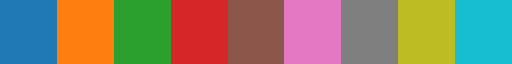

In [90]:
strain_cmap

## Compute p-values

In [91]:

# Collect p-values and corresponding (strain, metabolite) pairs
strain_metabolite_pairs = []
adjusted_p_values = []
all_p_values = []
uM_mean_std_dict = {}
for strain in exo_strains:
    p_values = []
    for metabolite in uM_metabolites:
        s_values = df_uMsamples.loc[strain, metabolite]
        wt_values = df_uMsamples.loc['WT', metabolite]
        s_mean = s_values.mean()
        wt_mean = wt_values.mean()
        s_std = s_values.std()
        wt_std = wt_values.std()
        uM_mean_std_dict[strain, metabolite] = {'Mean':s_mean, 'Std':s_std, 'N':len(s_values)}
        
        # if not np.isnan([s_mean, wt_mean, s_std, wt_std]).any():
        ttest_res = st.ttest_ind(s_values, wt_values, equal_var=False, alternative='two-sided')
        if not np.isnan(ttest_res.pvalue):
            p_values.append(ttest_res.pvalue)
            strain_metabolite_pairs.append((strain, metabolite))
        
    # Adjust p-values using the Benjamini-Hochberg procedure
    adjusted_p_values_s = multipletests(p_values, method='fdr_bh')[1]
    adjusted_p_values += adjusted_p_values_s.tolist()
    all_p_values += p_values
    # break
# Create a dictionary with adjusted p-values
adjusted_p_values_dict = {
    pair: adj_p for pair, adj_p in zip(strain_metabolite_pairs, adjusted_p_values)
}
p_values_dict = {
    pair: p_val for pair, p_val in zip(strain_metabolite_pairs, all_p_values)
}


In [ ]:

# Collect p-values and corresponding (strain, metabolite) pairs
strain_metabolite_pairs = []
adjusted_p_values = []
all_p_values = []
counts_mean_std_dict = {}
all_mean_differences = {}
log_diffs = {}
for strain in exo_strains:
    p_values = []
    for metabolite in z_metabolites:
        s_values = df_counts_samples.loc[strain, metabolite]
        wt_values = df_counts_samples.loc['WT', metabolite]
        s_mean = s_values.mean()
        wt_mean = wt_values.mean()
        s_std = s_values.std()
        wt_std = wt_values.std()
        counts_mean_std_dict[strain, metabolite] = {'Mean':s_mean, 'Std':s_std, 'N':len(s_values)}
        if strain != 'WT':
            log_diffs[strain, metabolite] = np.log10(s_mean) - np.log10(wt_mean)
            all_mean_differences[strain, metabolite] = s_mean - wt_mean
        ttest_res = st.ttest_ind(s_values, wt_values, equal_var=False, alternative='two-sided')
        if not np.isnan(ttest_res.pvalue):
            p_values.append(ttest_res.pvalue)
            strain_metabolite_pairs.append((strain, metabolite))
        
    # Adjust p-values using the Benjamini-Hochberg procedure
    adjusted_p_values_s = multipletests(p_values, method='fdr_bh')[1]
    adjusted_p_values += adjusted_p_values_s.tolist()
    all_p_values += p_values

# Create a dictionary with adjusted p-values
counts_adjusted_p_values_dict = {
    pair: adj_p for pair, adj_p in zip(strain_metabolite_pairs, adjusted_p_values)
}
counts_p_values_dict = {
    pair: p_val for pair, p_val in zip(strain_metabolite_pairs, all_p_values)
}


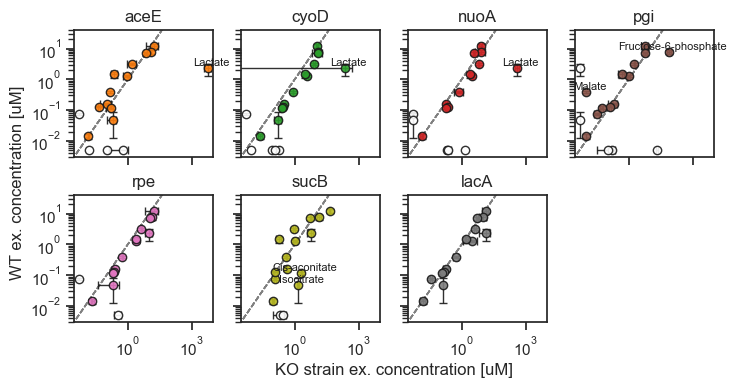

In [93]:
from matplotlib.ticker import LogLocator, NullFormatter

fig, axes = plt.subplots(2, 4, figsize=(8, 4), sharey=True, sharex = True)
axes = axes.flatten()
for i, strain in enumerate(exo_strains_x_wt):
    for j, m in enumerate(uM_metabolites):
        # print(strain, m)
        ax = axes[i]
        ax.set_title(strain)
        ax.set_xscale('log')
        ax.set_yscale('log')
        s_mean = uM_mean_std_dict[strain, m]['Mean']
        s_std = uM_mean_std_dict[strain, m]['Std']
        s_n = uM_mean_std_dict[strain, m]['N']
        wt_mean = uM_mean_std_dict['WT', m]['Mean']
        wt_std = uM_mean_std_dict['WT', m]['Std']
        wt_n = uM_mean_std_dict['WT', m]['N']

        if np.isnan(s_mean) and np.isnan(wt_mean):
            continue

        try:
            pvalue = p_values_dict[strain, m]
        except:
            pvalue = np.nan
        
        # if pvalue < 0.05:
        #     print(f'{strain} {m} {ttest_res.pvalue:.2e}')
        #     mecolor = 'k'
        # else:
        #     mecolor = 'gray'

        mecolor = 'k'
        if np.isnan(s_mean) or np.isnan(wt_mean):
            c = 'w'
            if np.isnan(s_mean):
                s_mean = 5e-3
            if np.isnan(wt_mean):
                wt_mean = 5e-3
        else:
            c = strain_colors[strain]


        ax.errorbar(
            x=s_mean,
            y = wt_mean,
            xerr=s_std,
            yerr=wt_std,
            fmt='o',
            # color='black',
            capsize=3,
            elinewidth=1,
            alpha=0.9,
            markeredgecolor=mecolor,
            ecolor=mecolor,#wt_mets_colors[m],
            c = c#strain_colors[strain],
        )
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        ax.plot([1e-4, 1e3], [1e-4, 1e3], ls = '--',c = 'gray', alpha=0.5, zorder=-10, lw = 1)


        # Annotate
        if np.abs(np.log10(uM_mean_std_dict[strain, m]['Mean']) - np.log10(uM_mean_std_dict['WT', m]['Mean'])) > 1:
            ax.annotate(
                m,
                xy=(uM_mean_std_dict[strain, m]['Mean'], uM_mean_std_dict['WT', m]['Mean']),
                xytext=(uM_mean_std_dict[strain, m]['Mean']*1.5, uM_mean_std_dict['WT', m]['Mean']*1.5),
                fontsize=8,
                ha='center',
                va='center',
                color = 'k', #strain_colors[strain],
            )
        # ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(3e-3, 1e4)
        ax.set_ylim(3e-3, 4e1)
        # ax.set_ylim(-4, 4)
        # Increase the number of ticks on the x-axis
        ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=4))  # Major ticks
        # ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=6))  # Minor ticks

axes[-1].remove()
fig.supylabel('WT ex. concentration [uM]', fontsize=12)
fig.supxlabel('KO strain ex. concentration [uM]', fontsize=12)
# plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.3, left = 0.1, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_exometabolome_wt_comparison_v1.pdf', bbox_inches='tight')

# Repeat, but with counts

In [94]:
counts_mean_std_dict

{('WT', '1, 3-diaminopropane'): {'Mean': np.float64(3182.921074350143),
  'Std': np.float64(472.00262802840047),
  'N': 3},
 ('WT', '2, 5-dihydroxybenzoate'): {'Mean': np.float64(21305.54673111277),
  'Std': np.float64(3360.2592067157616),
  'N': 3},
 ('WT', '2-hydroxybutyrate'): {'Mean': np.float64(1245.8139064551399),
  'Std': np.float64(99.3774561686364),
  'N': 3},
 ('WT', '2-hydroxyglutaric acid'): {'Mean': np.float64(4703.135330552873),
  'Std': np.float64(396.52618777238126),
  'N': 3},
 ('WT', '2-oxobutanoate/acetoacetate'): {'Mean': nan,
  'Std': np.float64(nan),
  'N': 3},
 ('WT',
  '3-(4-hydroxyphenyl)pyruvate'): {'Mean': np.float64(1780.4709022286434), 'Std': np.float64(68.94937548451763), 'N': 3},
 ('WT', '3-hydroxyanthranilate'): {'Mean': np.float64(7937.131061200321),
  'Std': np.float64(718.4786428236852),
  'N': 3},
 ('WT', '3-hydroxybutyrate'): {'Mean': np.float64(3182.3764590937267),
  'Std': np.float64(71.0512955006231),
  'N': 3},
 ('WT', '3-hydroxyglutaric acid'):

aceE 1, 3-diaminopropane (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)) 2923.2761165964134 3182.921074350143 0.6185867811373047 w
aceE 2, 5-dihydroxybenzoate (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)) 15102.641606100698 21305.54673111277 0.19127376073526775 w
aceE 2-hydroxybutyrate (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)) 14038.521429678447 1245.8139064551399 0.16138160636884796 w
aceE 2-hydroxyglutaric acid (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)) 15173.996578062333 4703.135330552873 0.07028783597262146 w
aceE 2-oxobutanoate/acetoacetate (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)) 6481.957968353466 nan nan gray
aceE 3-(4-hydroxyphenyl)pyruvate (np.float64(1.0), np.float64(0.4980392156862745), np.float

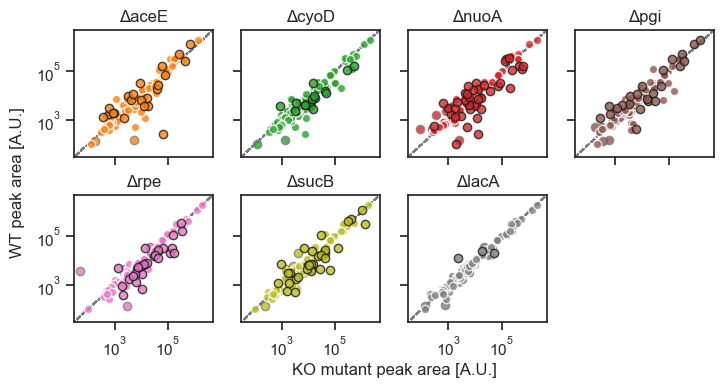

In [95]:
annotate = False
plot_nan = False
fig, axes = plt.subplots(2, 4, figsize=(8, 4), sharey=True, sharex = True)
axes = axes.flatten()
for i, strain in enumerate(exo_strains_x_wt):
    for j, m in enumerate(z_metabolites):
        ax = axes[i]
        ax.set_title(f'Δ{strain}')
        ax.set_xscale('log')
        ax.set_yscale('log')
        s_mean = counts_mean_std_dict[strain, m]['Mean']
        wt_mean = counts_mean_std_dict['WT', m]['Mean']
        
        c = strain_colors[strain]
        if plot_nan:
            if np.isnan(s_mean) or np.isnan(wt_mean):
                c = 'w'
                if np.isnan(s_mean):
                    s_mean = 10
                if np.isnan(wt_mean):
                    wt_mean = 10
        
        

        try:
            pvalue = counts_adjusted_p_values_dict[strain, m]
        except:
            pvalue = np.nan
        
        if pvalue < 0.05:
            # print(f'{strain} {m} {pvalue:.2e}')
            mecolor = 'k'
            zorder = 100
        elif np.isnan(pvalue):
            mecolor = 'gray'
            zorder = 0
        else:
            mecolor = 'w'
            zorder = 10
        print(strain, m, c, s_mean, wt_mean, pvalue, mecolor)

        # mecolor = 'k'
        ax.errorbar(
            x=s_mean,
            y=wt_mean,
            # xerr=counts_mean_std_dict[strain, m]['Std'],
            # yerr=counts_mean_std_dict['WT', m]['Std'],
            fmt='o',
            # color='black',
            capsize=3,
            elinewidth=1,
            alpha=0.8,
            markeredgecolor=mecolor,
            # ecolor=mecolor,#wt_mets_colors[m],
            markerfacecolor = c,#'gray',
            zorder=zorder,
        )
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        ax.plot([1e-2, 1e7], [1e-2, 1e7], ls = '--',c = 'gray', alpha=0.5, zorder=-10, lw = 1)

        # Annotate
        if annotate:
            if np.abs(np.log10(s_mean) - np.log10(wt_mean)) > 1:
                ax.annotate(
                    m,
                    xy=(counts_mean_std_dict[strain, m]['Mean'], counts_mean_std_dict['WT', m]['Mean']),
                    xytext=(counts_mean_std_dict[strain, m]['Mean']*1.5, counts_mean_std_dict['WT', m]['Mean']*1.5),
                    fontsize=8,
                    ha='center',
                    va='center',
                    # fontweight='bold',
                    color = 'k', #strain_colors[strain],
                )
        # ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(30, 5e6)
        ax.set_ylim(30, 5e6)
        # ax.set_ylim(-4, 4)
        # Increase the number of ticks on the x-axis
        ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=4))  # Major ticks
        ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=4))  # Major ticks
        # ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=6))  # Minor ticks

axes[-1].remove()
fig.supylabel('WT peak area [A.U.]', fontsize=12)
fig.supxlabel('KO mutant peak area [A.U.]', fontsize=12)
# plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.3, left = 0.1, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_exometabolome_wt_comparison_v1_counts.pdf', bbox_inches='tight')

# Print statistics

In [96]:
# Print statistics
counts_diffs = []
for i, strain in enumerate(exo_strains_x_wt):
    for j, m in enumerate(z_metabolites):
        try:
            pvalue = counts_adjusted_p_values_dict[strain, m]
        except:
            pvalue = np.nan
        # pvalue = counts_adjusted_p_values_dict[strain, m]
        s_mean = counts_mean_std_dict[strain, m]['Mean']
        wt_mean = counts_mean_std_dict['WT', m]['Mean']
        s_std = counts_mean_std_dict[strain, m]['Std']
        wt_std = counts_mean_std_dict['WT', m]['Std']
        if np.isnan(wt_mean) and not np.isnan(s_mean*s_std):
            pvalue = 1e-10
        counts_diffs.append((strain, m, pvalue, s_mean, wt_mean, s_std, wt_std))
df_counts_diffs = pd.DataFrame(counts_diffs, columns=['Strain', 'Metabolite', 'adj. pvalue', 'Strain_mean', 'WT_mean', 'Strain_std', 'WT_std'])

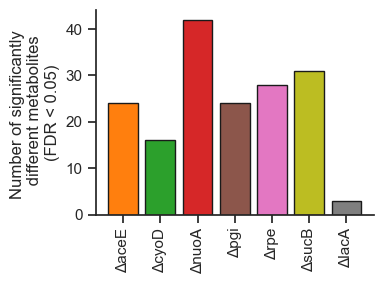

In [97]:

# Plot bar chart with the number of significant metabolites for each strain
significance_threshold = 0.05
n_sig = (
    df_counts_diffs[df_counts_diffs.Strain != 'WT']
    .groupby('Strain')
    .apply(lambda d: (d['adj. pvalue'] < significance_threshold).sum(), include_groups=False)
    .rename('N_significant')
    .reindex(exo_strains_x_wt)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(
    range(len(n_sig)),
    n_sig['N_significant'],
    color=[strain_colors[s] for s in n_sig['Strain']],
    edgecolor='k',
    linewidth=1,
)
ax.set_xticks(range(len(n_sig)))
ax.set_xticklabels([f'Δ{s}' for s in n_sig['Strain']], rotation=90, ha='center')
# ax.set_xlabel('Strain')
ax.set_ylabel('Number of significantly \n different metabolites\n(FDR < 0.05)')
# ax.set_title('Significant exometabolome changes per KO strain')
sns.despine()
plt.tight_layout()
plt.savefig(figure_folder / 'KEIO_n_significant_metabolites_per_strain.pdf', bbox_inches='tight')
plt.show()


In [98]:
uM_diffs = []
for i, strain in enumerate(exo_strains_x_wt):
    for j, m in enumerate(uM_metabolites):
        try:
            pvalue = adjusted_p_values_dict[strain, m]
        except:
            pvalue = np.nan
        # pvalue = counts_adjusted_p_values_dict[strain, m]
        s_mean = uM_mean_std_dict[strain, m]['Mean']
        wt_mean = uM_mean_std_dict['WT', m]['Mean']
        s_std = uM_mean_std_dict[strain, m]['Std']
        wt_std = uM_mean_std_dict['WT', m]['Std']
        if np.isnan(wt_mean) and not np.isnan(s_mean*s_std):
            pvalue = 1e-10
        uM_diffs.append((strain, m, pvalue, s_mean, wt_mean, s_std, wt_std))
df_uM_diffs = pd.DataFrame(uM_diffs, columns=['Strain', 'Metabolite', 'adj. pvalue', 'Strain_mean', 'WT_mean', 'Strain_std', 'WT_std'])

In [99]:
df_uM_diffs['WT ref'] = [x if not np.isnan(x) else 0 for x in df_uM_diffs['WT_mean'] ]

In [100]:
df_uM_diffs['Difference'] = df_uM_diffs['Strain_mean'] - df_uM_diffs['WT ref']

In [101]:

df_uM_diffs.sort_values('Difference', ascending=False).head(20)

,Strain,Metabolite,adj. pvalue,Strain_mean,WT_mean,Strain_std,WT_std,WT ref,Difference
13,aceE,Lactate,1.183845e-01,5738.903655,2.261028,2034.525794,0.943209,2.261028,5736.642627
51,nuoA,Lactate,2.755500e-02,387.567520,2.261028,72.165452,0.943209,2.261028,385.306492
32,cyoD,Lactate,3.031223e-01,219.871394,2.261028,255.302359,0.943209,2.261028,217.610365
64,pgi,Fructose-6-phosphate,3.354869e-02,78.869484,7.735606,17.284474,1.317779,7.735606,71.133879
101,sucB,Citrate,1.126798e-03,43.715313,12.512888,2.552066,1.992018,12.512888,31.202425
66,pgi,Glucose-6-phosphate,1.000000e-10,20.689664,NaN,2.345093,NaN,0.000000,20.689664
127,lacA,Lactate,3.135969e-01,13.692189,2.261028,7.368799,0.943209,2.261028,11.431161
89,rpe,Lactate,7.219963e-02,9.687793,2.261028,3.554023,0.943209,2.261028,7.426764
102,sucB,Fructose-6-phosphate,5.480013e-02,13.862113,7.735606,2.532979,1.317779,7.735606,6.126507
83,rpe,Fructose-6-phosphate,1.052639e-01,13.261023,7.735606,3.478979,1.317779,7.735606,5.525417


In [102]:
p_values_dict['aceE', 'Lactate']

np.float64(0.03946148607440755)

In [103]:
# Get the top 5 significant metabolites (lowest adj. pvalue) for each strain
top5_metabolites = (
    df_uM_diffs
    .sort_values(['Strain', 'adj. pvalue'])
    .groupby('Strain')
    .head(5)
    .reset_index(drop=True)
)
display(top5_metabolites[['Strain', 'Metabolite', 'adj. pvalue']])# Get the top 5 significant metabolites (lowest adj. pvalue) for each strain


,Strain,Metabolite,adj. pvalue
0,aceE,Valine,1.000000e-10
1,aceE,Fructose-6-phosphate,1.183845e-01
2,aceE,Gamma-aminobutyrate,1.183845e-01
3,aceE,Lactate,1.183845e-01
4,aceE,Leucine,1.474249e-01
5,cyoD,Glutamine,1.000000e-10
6,cyoD,Valine,1.000000e-10
7,cyoD,Malate,8.272377e-03
8,cyoD,Alanine,2.713135e-02
9,cyoD,Cis-aconitate,2.713135e-02


In [104]:
# Get the top 5 significant metabolites (lowest adj. pvalue) for each strain
top5_metabolites = (
    df_counts_diffs
    .sort_values(['Strain', 'adj. pvalue'])
    .groupby('Strain')
    .head(5)
    .reset_index(drop=True)
)
display(top5_metabolites[['Strain', 'Metabolite', 'adj. pvalue']])# Get the top 5 significant metabolites (lowest adj. pvalue) for each strain


,Strain,Metabolite,adj. pvalue
0,aceE,2-oxobutanoate/acetoacetate,1.000000e-10
1,aceE,Pyruvate,1.000000e-10
2,aceE,3-hydroxybutyrate,2.621170e-04
3,aceE,cAMP,1.391094e-03
4,aceE,Ethanolamine,2.162208e-02
5,cyoD,Oxoproline,1.396029e-02
6,cyoD,2-hydroxyglutaric acid,2.759011e-02
7,cyoD,3-hydroxyglutaric acid,2.759011e-02
8,cyoD,Adenosine,2.759011e-02
9,cyoD,Malate,2.759011e-02


In [105]:
# Calculate the fraction of significant metabolites for each strain
significance_threshold = 0.05
fraction_significant = (
    df_counts_diffs
    .groupby('Strain')
    .apply(lambda df: (df['adj. pvalue'] < significance_threshold).mean())
    .rename('Fraction_significant')
    .reset_index()
)
display(fraction_significant)

# Calculate the fraction of significant metabolites for each strain
significance_threshold = 0.05
N_significant = (
    df_counts_diffs
    .groupby('Strain')
    .apply(lambda df: (df['adj. pvalue'] < significance_threshold).sum())
    .rename('N_significant')
    .reset_index()
)
display(N_significant)
print(df_counts_diffs.Metabolite.nunique())

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_32553/879466117.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_counts_diffs


,Strain,Fraction_significant
0,aceE,0.216216
1,cyoD,0.144144
2,lacA,0.027027
3,nuoA,0.378378
4,pgi,0.216216
5,rpe,0.252252
6,sucB,0.279279


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_32553/879466117.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_counts_diffs


,Strain,N_significant
0,aceE,24
1,cyoD,16
2,lacA,3
3,nuoA,42
4,pgi,24
5,rpe,28
6,sucB,31


111


In [106]:
22/111


0.1981981981981982

In [107]:
df_log_diffs = pd.Series(log_diffs).reset_index()
df_log_diffs.columns = ['Strain', 'Metabolite', 'LogDiff']

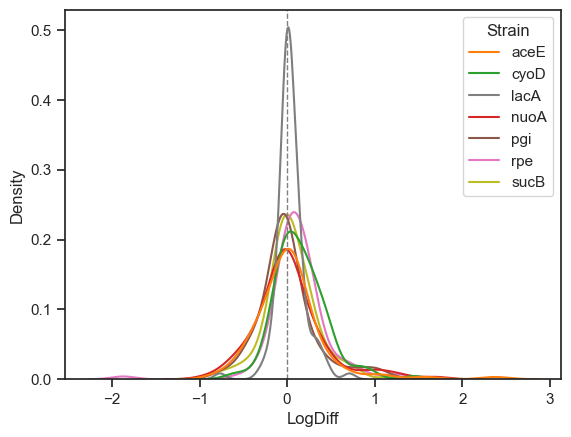

In [108]:
# log_diff = 
ax = sns.kdeplot(data = df_log_diffs, x = 'LogDiff', hue = 'Strain', palette=strain_colors)
ax.axvline(0, ls = '--', c = 'gray', lw = 1)


In [109]:
df_log_diffs.dropna(inplace=True)

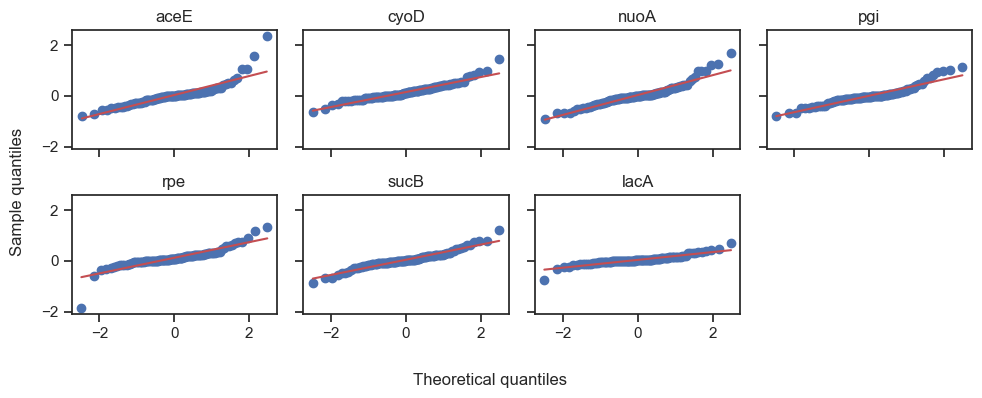

In [110]:
fig, axes = plt.subplots(2, 4, figsize=(10, 4), sharex=True, sharey=True)
axes = axes.flatten()
for i, strain in enumerate(exo_strains_x_wt):
    ax = axes[i]
    df_log_diffs_s = df_log_diffs.loc[df_log_diffs.Strain == strain]
    # print(df_log_diffs_s)
    # print(st.probplot(df_log_diffs_s.LogDiff, dist="norm", plot=plt, ))
    st.probplot(df_log_diffs_s.LogDiff, dist="norm", plot=ax, fit = True)#, rvalue=True)
    ax.set_title(strain)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_xlim(-3, 3)
    # ax.set_ylim(-3, 3)
fig.supxlabel('Theoretical quantiles', fontsize=12)
fig.supylabel('Sample quantiles', fontsize=12)
axes[-1].remove()
plt.tight_layout()
# st.probplot(df_log_diffs.LogDiff, dist="norm", plot=plt, )

In [111]:

wt_mets = sorted(df_uM.loc[df_uM.Strain == 'WT', df_uM.loc[df_uM.Strain == 'WT'].notna().any()].columns[1:-4])

In [112]:
mets_cmap = plt.get_cmap('tab20', len(wt_mets))
wt_mets_colors = {m: mets_cmap(i) for i, m in enumerate(wt_mets)}

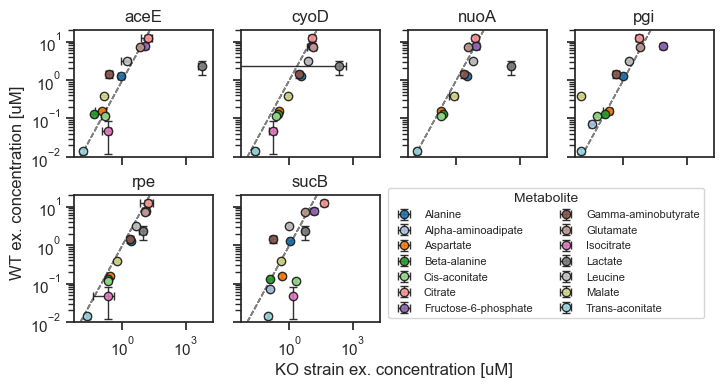

In [113]:
from matplotlib.ticker import LogLocator, NullFormatter

fig, axes = plt.subplots(2, 4, figsize=(8, 4), sharey=True, sharex = True)
axes = axes.flatten()
for i, strain in enumerate(exo_strains_x_wt):
    if strain == 'lacA':
        continue
    for j, m in enumerate(uM_metabolites):
        ax = axes[i]
        ax.set_title(strain)
        ax.set_xscale('log')
        ax.set_yscale('log')
        x_mean = uM_mean_std_dict[strain, m]['Mean']
        y_mean = uM_mean_std_dict['WT', m]['Mean']
        if np.isnan(x_mean) or np.isnan(y_mean):
            continue
        ax.errorbar(
            x=x_mean,
            y=y_mean,
            xerr=uM_mean_std_dict[strain, m]['Std'],
            yerr=uM_mean_std_dict['WT', m]['Std'],
            fmt='o',
            # color='black',
            capsize=3,
            elinewidth=1,
            alpha=0.9,
            markeredgecolor='k',
            ecolor='k',#wt_mets_colors[m],
            c = wt_mets_colors[m],
            label = m,
        )
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        ax.plot([1e-2, 1e3], [1e-2, 1e3], ls = '--',c = 'gray', alpha=0.5, zorder=-10, lw = 1)

        # ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(5e-3, 2e4)
        ax.set_ylim(1e-2, 2e1)
        # ax.set_ylim(-4, 4)
        # Increase the number of ticks on the x-axis
        ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=4))  # Major ticks
        # ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=6))  # Minor ticks

axes[-3].legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.1),
    fontsize=8,
    title='Metabolite',
    title_fontsize='10',
    frameon=True,
    ncol=2,
)
axes[-1].remove()
axes[-2].remove()

fig.supylabel('WT ex. concentration [uM]', fontsize=12)
fig.supxlabel('KO strain ex. concentration [uM]', fontsize=12)
# plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.3, left = 0.1, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_exometabolome_wt_comparison_v2.pdf', bbox_inches='tight')

## PCA of z_score


In [114]:
X_df = df_z_scores_samples[z_metabolites].copy()

In [115]:
X_df = X_df.apply(lambda col: col.fillna(col.min()), axis = 0)

In [116]:
X = StandardScaler().fit_transform(X_df)

pca = PCA(n_components=2)
Xn = pca.fit_transform(X)
pca_df = pd.DataFrame(
    data = Xn,
    columns = ['PC1', 'PC2'],
    index = df_z_scores_samples.Sample_id,
)
pca_df['Strain'] = df_z_scores_samples.Strain.values


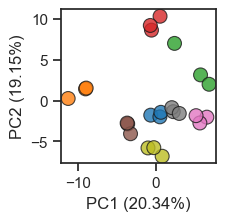

In [117]:
fig, ax = plt.subplots(figsize=(2, 2))
pca_df.sort_values(by = 'Strain', inplace=True)
sns.scatterplot(
    data = pca_df,
    x = 'PC1',
    y = 'PC2',
    hue = 'Strain',
    palette = strain_colors,
    alpha = 0.8,
    edgecolor = 'k',
    s = 100,
    ax=ax,
    legend=False,
    )
ax.set_xlabel('PC1 (%.2f%%)' % (pca.explained_variance_ratio_[0] * 100))
ax.set_ylabel('PC2 (%.2f%%)' % (pca.explained_variance_ratio_[1] * 100))
# sns.despine()
plt.savefig(figure_folder / 'KEIO_exometabolome_pca.pdf', bbox_inches='tight')

# Plot growth curves and yield from tubes

In [118]:
df_od_tubes = pd.read_csv(fn_tubes, index_col=0)
df_od_tubes.rename(columns={'Hours': 'Time [h]'}, inplace=True) 

# only keep data fro strains we did exomtabolome on
df_od_tubes = df_od_tubes.loc[df_od_tubes.Strain.isin(exo_strains)]

# strains = sorted(df_od_tubes.Strain.unique())
replicates = ['A', 'B', 'C']

yield_df = df_od_tubes.groupby(['Strain', 'Replicate']).agg({'OD600': 'max'}).reset_index()

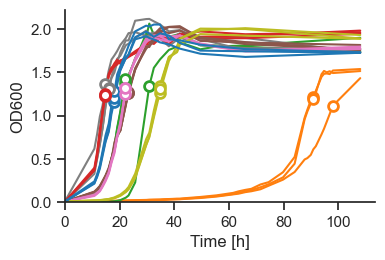

In [119]:
fig, ax = plt.subplots(figsize=(4, 2.5))
ax = sns.lineplot(data = df_od_tubes, x = 'Time [h]', y = 'OD600', hue = 'Strain',# style = 'Replicate',
                   palette = strain_colors, markers=True, units='Replicate', estimator=None, legend=False)# marker = 'o')
# sns.move_legend(ax, loc = 'upper left', bbox_to_anchor=(1, 1), title = 'Strain', fontsize = 10)
for strain in exo_strains:
    for replicate in replicates:
        idx = (df_uM.Strain == strain) & ( df_uM.Replicate == replicate)
        time = df_uM.loc[idx, 'Hours'].values[0]
        od = df_uM.loc[idx, 'OD'].values[0]
        ax.scatter(
            x = time,
            y = od,
            color = 'w',
            marker = 'o',
            s = 50,
            edgecolor = strain_colors[strain],
            linewidth = 2,
            zorder = 100

            # label = f'{strain} {replicate}',
        )

# plt.yscale('log')
sns.despine()
ax.set_ylim(0)
ax.set_xlim(0)
plt.savefig(figure_folder / '2A_screening_tubes_OD.pdf', bbox_inches='tight')

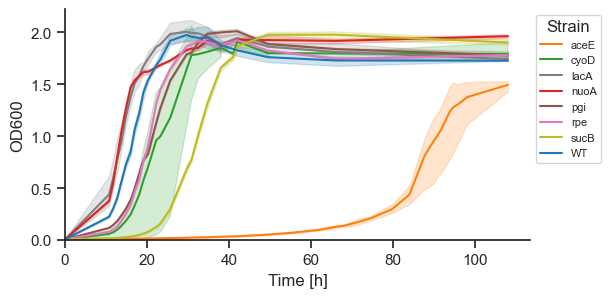

In [120]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = sns.lineplot(data = df_od_tubes, x = 'Time [h]', y = 'OD600', hue = 'Strain', 
                  palette = strain_colors)
sns.move_legend(ax, loc = 'upper left', bbox_to_anchor=(1, 1), title = 'Strain', fontsize = 8)
sns.despine()
ax.set_ylim(0)
ax.set_xlim(0)
plt.savefig(figure_folder / '2A_screening_tubes_OD_error_band.pdf', bbox_inches='tight')

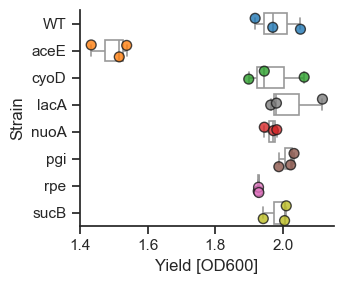

In [121]:

g = sns.catplot(data = yield_df, y = 'Strain', x = 'OD600',hue = 'Strain', 
                aspect=1.2, s = 50, height=3, alpha = 0.8, jitter = 0.3, edgecolor='k',
                  linewidth = 1, palette=strain_colors, order=exo_strains)
g.map_dataframe(sns.boxplot, y = 'Strain', x = 'OD600', color = 'w', fliersize = 0, linewidth = 1.2)
g.set_axis_labels('Yield [OD600]', 'Strain')
plt.savefig(figure_folder / 'strain_yield.pdf', bbox_inches='tight')

### Get growth rates

In [122]:
df_od_tubes

,Sample ID,Strain,Time [h],OD600,Replicate
0,1A,aceE,0.0,0.008,A
1,1B,aceE,0.0,0.003,B
2,1C,aceE,0.0,0.007,C
3,2A,cyoD,0.0,0.009,A
4,2B,cyoD,0.0,0.006,B
...,...,...,...,...,...
1375,8B,sucB,108.0,1.891,B
1376,8C,sucB,108.0,1.887,C
1383,11A,WT,108.0,1.726,A
1384,11B,WT,108.0,1.727,B


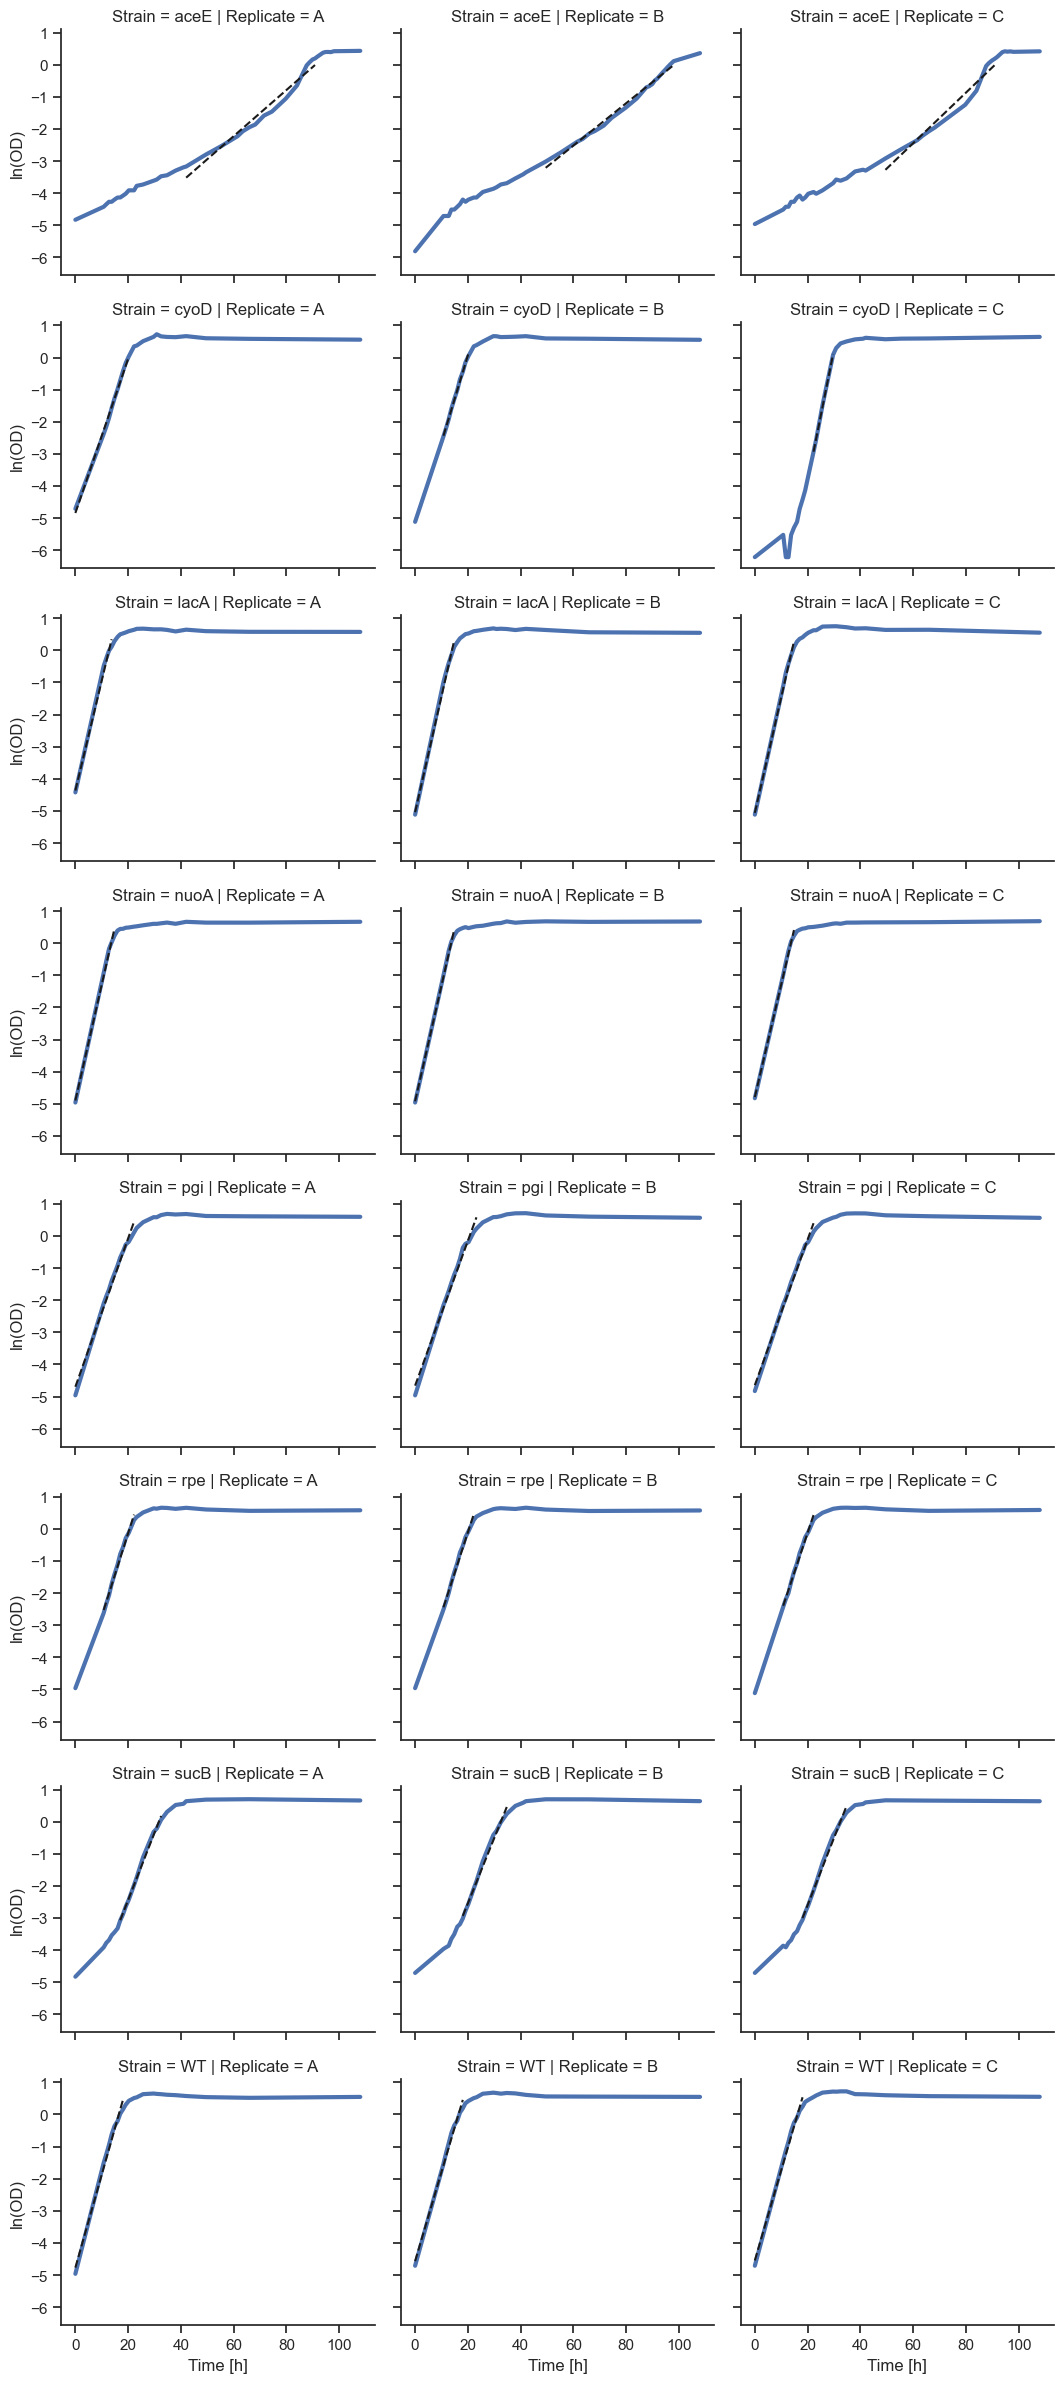

In [123]:
df_od_tubes['ln(OD)'] = np.log([x for x in df_od_tubes['OD600']])
g = sns.relplot(data=df_od_tubes, x = 'Time [h]', y = 'ln(OD)', row = 'Strain', col = 'Replicate', kind = 'line', lw = 3, height = 3, aspect = 1.2)
data = []
od_range = [0.05, 1.2]
for sample_id in df_od_tubes['Sample ID'].unique():
    idx = (df_od_tubes['Sample ID']==sample_id)
    dfi = df_od_tubes.loc[idx]
    strain = dfi.Strain.iloc[0]
    rep = sample_id[-1]
    ax = g.axes_dict[(strain, rep)]
    
    idx0 = (dfi['OD600']-od_range[0]).abs().argmin()
    idx1 = (dfi['OD600']-od_range[1]).abs().argmin()
    
    ln_OD = dfi.iloc[idx0:idx1+1]['ln(OD)']
    hours = dfi.iloc[idx0:idx1+1]['Time [h]']
    fit = np.polyfit(hours, ln_OD, 1)
    x_arr = np.linspace(hours.min(), hours.max(), 2)
    y_arr = x_arr*fit[0]+fit[1]
    # delta_ln_OD = - dfi.iloc[idx0]['ln(OD)']
    # delta_t = dfi.Hours.iloc[idx1]-dfi.Hours.iloc[idx0]
    # growth_rate = delta_ln_OD/delta_t
    growth_rate = fit[0]
    data.append([strain, rep, growth_rate])

    # Plot
    # ax.plot([dfi.Hours.iloc[idx0], dfi.Hours.iloc[idx1]], [dfi.iloc[idx0]['ln(OD)'], dfi.iloc[idx1]['ln(OD)']], c = 'k', ls = '--')
    ax.plot(x_arr, y_arr, c = 'k', ls = '--')
    
df_tube_rate = pd.DataFrame(data, columns = ['Strain', 'Replicate', 'Growth rate'])       

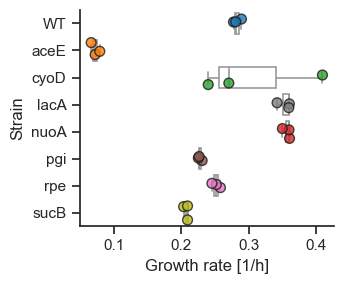

In [124]:



g = sns.catplot(df_tube_rate, x = 'Growth rate', y = 'Strain', hue = 'Strain', order = exo_strains, palette=strain_colors,
                aspect=1.2, s = 50, height=3, alpha = 0.8, jitter = 0.3, edgecolor='k',
                  linewidth = 1)
g.map_dataframe(sns.boxplot, y = 'Strain', x = 'Growth rate', color = 'w', fliersize = 0, linewidth = 1.2)
g.set_axis_labels('Growth rate [1/h]', 'Strain')
plt.savefig(figure_folder / 'strain_rate.pdf', bbox_inches='tight')

# Plot metabolomics data

In [125]:
# Make long data frame
dfL_counts = pd.melt(df_counts_samples.reset_index(), id_vars=['Strain', 'Sample_id'], var_name='Metabolite', value_name='Counts', value_vars=z_metabolites)
dfL_uM = pd.melt(df_uMsamples.reset_index(), id_vars=['Strain', 'Sample_id'], var_name='Metabolite', value_name='Concentration [uM]', value_vars=uM_metabolites)

# Estimate distance from KO

In [126]:

import networkx as nx
from reframed import load_cbmodel

# ── 1. Load iJO1366 ────────────────────────────────────────────────────────────
model_path = git_folder / 'models' / 'e_coli' / 'iML1515.xml'
m = load_cbmodel(str(model_path))

# ── 2. Currency metabolites to skip ───────────────────────────────────────────
CURRENCY = {
    'h2o', 'h', 'atp', 'adp', 'amp', 'nad', 'nadh', 'nadp', 'nadph',
    'fad', 'fadh2', 'pi', 'ppi', 'coa', 'co2', 'o2', 'hco3', 'nh4',
}
def is_currency(met_id):
    bigg = met_id[2:].rsplit('_', 1)[0]
    return bigg in CURRENCY

def get_compartment(met_id):
    return met_id.rsplit('_', 1)[-1]

def is_transport(rxn):
    compartments = {get_compartment(mid) for mid in rxn.stoichiometry}
    return len(compartments) > 1

EXCLUDE_REACTIONS = {'R_BIOMASS_Ec_iJO1366_WT_53p95M', 'R_BIOMASS_Ec_iJO1366_core_53p95M'}

# KO reactions to always include (even if transport)
strain_gene_ids = {
    'aceE': 'G_b0114',
    # 'cyoD': 'G_b0429',
    # 'nuoA': 'G_b2288',
    'pgi':  'G_b4025',
    'rpe':  'G_b3386',
    'sucB': 'G_b0727',
    'lacA': None,
}
gene_to_rxns_all = {}
for rid, rxn in m.reactions.items():
    for gid in rxn.get_genes():
        gene_to_rxns_all.setdefault(gid, []).append(rid)

KO_REACTIONS = {r for gid in strain_gene_ids.values() if gid
                for r in gene_to_rxns_all.get(gid, [])}

# ── 3. Build bipartite graph ───────────────────────────────────────────────────
B = nx.Graph()
for rid, rxn in m.reactions.items():
    if rid in EXCLUDE_REACTIONS:
        continue
    if is_transport(rxn) and rid not in KO_REACTIONS:
        continue
    mets = [mid for mid in rxn.stoichiometry if not is_currency(mid)]
    if not mets:
        continue
    B.add_node(rid, bipartite='reaction')
    for mid in mets:
        B.add_node(mid, bipartite='metabolite')
        B.add_edge(mid, rid)

print(f'Bipartite graph: {B.number_of_nodes()} nodes '
      f'({sum(1 for n,d in B.nodes(data=True) if d.get("bipartite")=="metabolite")} metabolites, '
      f'{sum(1 for n,d in B.nodes(data=True) if d.get("bipartite")=="reaction")} reactions), '
      f'{B.number_of_edges()} edges')

# ── 4. Map KO genes → KO reaction nodes ───────────────────────────────────────
strain_source_rxns = {}
strain_source_mets = {}
for strain, gid in strain_gene_ids.items():
    if gid is None:
        strain_source_rxns[strain] = set()
        strain_source_mets[strain] = set()
        continue
    rxns = [r for r in gene_to_rxns_all.get(gid, []) if r in B]
    mets = {mid for r in rxns for mid in m.reactions[r].stoichiometry
            if not is_currency(mid) and mid in B}
    if not mets:
        mets = {mid for r in rxns for mid in m.reactions[r].stoichiometry if mid in B}
    strain_source_rxns[strain] = set(rxns)
    strain_source_mets[strain] = mets
    print(f'{strain}: KO reactions={rxns}')

# ── 5. BiGG mapping ───────────────────────────────────────────────────────────
bigg_df = pd.read_csv(git_folder / 'data' / 'this_project' / '2_keio_strains_screening' / '2F_metabolomics_name_to_bigg.csv')
name_to_bigg = bigg_df.dropna(subset=['BiGG ID']).set_index('Metabolite')['BiGG ID'].to_dict()

bigg_to_nodes = {}
for nid in B.nodes():
    if not nid.startswith('M_'):
        continue
    if not nid.endswith('_c'):
        continue
    bigg = nid[2:].rsplit('_', 1)[0]
    bigg_to_nodes.setdefault(bigg, []).append(nid)

def met_name_to_nodes(name):
    bigg = name_to_bigg.get(name)
    if bigg is None:
        return []
    return bigg_to_nodes.get(bigg, [])

# ── 6. BFS: return full bipartite path ────────────────────────────────────────
def min_reaction_distance_with_path(B, source_rxns, targets):
    """Returns (distance_in_reactions, full bipartite path node list)."""
    if not source_rxns or not targets:
        return np.nan, None
    best_d = np.inf
    best_path = None
    for t in targets:
        if t not in B:
            continue
        for s in source_rxns:
            try:
                path = nx.shortest_path(B, s, t)
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                continue
            rxn_nodes = [n for n in path if not n.startswith('M_')]
            rxn_d = len(rxn_nodes) - 1   # KO reaction itself is step 0
            if rxn_d < best_d:
                best_d = rxn_d
                best_path = path
    if best_d == np.inf:
        return np.nan, None
    return best_d, best_path

def format_path(path):
    """Format full bipartite path as: RXN1 (met1) -> RXN2 (met2) -> ..."""
    if path is None:
        return None
    parts = []
    for i, node in enumerate(path):
        if node.startswith('M_'):
            if 0 < i < len(path) - 1:
                met_bigg = node[2:].rsplit('_', 1)[0]
                parts.append(f'({met_bigg})')
        else:
            parts.append(node[2:])   # strip 'R_'
    return ' -> '.join(parts)

# ── 7. Compute distance matrix with path column ───────────────────────────────
measured_mets = sorted(dfL_counts['Metabolite'].unique())
strains_order = list(strain_gene_ids.keys())

rows = []
for strain in strains_order:
    sources = strain_source_rxns[strain]
    for met in measured_mets:
        targets = met_name_to_nodes(met)
        dist, path = min_reaction_distance_with_path(B, sources, targets)
        rows.append({'Strain': strain, 'Metabolite': met,
                     'Reaction distance': dist, 'Path (reactions)': format_path(path)})

df_dist = pd.DataFrame(rows)
mapped = df_dist['Reaction distance'].notna().sum()
print(f'\nDistance matrix: {len(df_dist)} entries, {mapped} mapped ({mapped/len(df_dist)*100:.0f}%)')
print(df_dist.dropna(subset=['Reaction distance']).groupby('Strain')['Reaction distance'].describe().round(1))
display(df_dist.dropna(subset=['Reaction distance']).sort_values(['Strain','Reaction distance']).head(20))


Bipartite graph: 3458 nodes (1599 metabolites, 1859 reactions), 4433 edges
aceE: KO reactions=['R_PDH']
pgi: KO reactions=['R_PGI']
rpe: KO reactions=['R_RPE']
sucB: KO reactions=['R_AKGDH']

Distance matrix: 555 entries, 292 mapped (53%)
        count  mean  std  min  25%  50%  75%  max
Strain                                           
aceE     73.0   2.1  0.9  0.0  2.0  2.0  3.0  4.0
pgi      73.0   2.7  1.0  0.0  2.0  3.0  3.0  4.0
rpe      73.0   3.1  0.8  1.0  3.0  3.0  4.0  4.0
sucB     73.0   2.3  1.0  1.0  2.0  2.0  3.0  5.0


,Strain,Metabolite,Reaction distance,Path (reactions)
88,aceE,Pyruvate,0.0,PDH
4,aceE,2-oxobutanoate/acetoacetate,1.0,PDH -> (pyr) -> ACHBS
16,aceE,Alanine,1.0,PDH -> (pyr) -> ALATA_L2
19,aceE,Anthranilate,1.0,PDH -> (pyr) -> ANS
29,aceE,Citrate,1.0,PDH -> (accoa) -> CS
44,aceE,Glutamate,1.0,PDH -> (pyr) -> ALATA_L
45,aceE,Glutamine,1.0,PDH -> (pyr) -> ANS
50,aceE,Glycerol 3-phosphate,1.0,PDH -> (pyr) -> EDA
53,aceE,Hexanoate,1.0,PDH -> (accoa) -> HXCT
55,aceE,Hexoses,1.0,PDH -> (accoa) -> GLCATr


In [127]:

# Diagnose unmapped metabolites
no_bigg = []
bigg_not_in_model = []

for met in sorted(dfL_counts['Metabolite'].unique()):
    bigg = name_to_bigg.get(met)
    if bigg is None:
        no_bigg.append(met)
    elif not bigg_to_nodes.get(bigg):
        bigg_not_in_model.append((met, bigg))

print(f"=== No BiGG ID ({len(no_bigg)}) ===")
for m in no_bigg:
    print(f"  {m}")

print(f"\n=== BiGG ID not in model ({len(bigg_not_in_model)}) ===")
for m, b in bigg_not_in_model:
    if b in CURRENCY:
        continue
    print(f"  {m}  ->  {b}")


=== No BiGG ID (23) ===
  1, 3-diaminopropane
  3-hydroxyanthranilate
  3-hydroxyphenylacetate
  Adenosine 3', 5'-cyclic phosphate
  Adipate
  Alpha-hydroxyisobutyrate
  Epinephrine
  Glucuronolactone
  Glutarylcarnitine (c5-dc)
  Guanidinosuccinate
  Hexanoylcarnitine (c6)
  Kynurenate
  Malonylcarnitine (c3:dc)
  Methylguanidine
  N,n,n-trimethyllysine
  N-acetylaspartate
  N-acetylphenylalanine
  Ophthalmate
  Pyrimidine
  Stearoylcarnitine (c18)
  Trigonelline
  Tryptamine
  Xanthurenate

=== BiGG ID not in model (12) ===
  4-acetamidobutanoate  ->  4aabutn
  4-imidazoleacetate  ->  im4ac
  Glutarate  ->  glutar
  Hydroxyphenyllactate  ->  2hyoxplac
  N-acetylleucine  ->  acleu__L
  N-acetylputrescine  ->  aprut
  N-alpha-acetyllysine  ->  aclys
  Oxoproline  ->  5oxpro
  Salicylate  ->  salc
  Tyramine  ->  tym


In [128]:
bigg_to_nodes[name_to_bigg["Adenosine 3', 5'-cyclic phosphate"]]

KeyError: "Adenosine 3', 5'-cyclic phosphate"

In [ ]:
# Not reachable
df_dist.loc[df_dist['Metabolite'] == "Adenosine 3', 5'-cyclic phosphate"]

,Strain,Metabolite,Reaction distance,Path (reactions)
13,aceE,"Adenosine 3', 5'-cyclic phosphate",NaN,None
124,pgi,"Adenosine 3', 5'-cyclic phosphate",NaN,None
235,rpe,"Adenosine 3', 5'-cyclic phosphate",NaN,None
346,sucB,"Adenosine 3', 5'-cyclic phosphate",NaN,None
457,lacA,"Adenosine 3', 5'-cyclic phosphate",NaN,None


In [ ]:

# Helper: annotate a catplot FacetGrid with reaction distances from df_dist
def annotate_reaction_distances(g, exo_strains, df_dist, fontsize=14, color='dimgrey'):
    """Add reaction-distance numbers above each strain's data in every panel."""
    dist_lookup = (df_dist.dropna(subset=['Reaction distance'])
                   .set_index(['Strain', 'Metabolite'])['Reaction distance']
                   .to_dict())
    for ax in g.axes.flat:
        metabolite = ax.get_title()
        if not metabolite:
            continue
        ymin, ymax = ax.get_ylim()
        y_pos = ymax * 1.1   # just below the top of the axes
        ax.set_ylim(ymin, ymax * 1.15)  # make room for the text
        for xi, strain in enumerate(exo_strains):
            d = dist_lookup.get((strain, metabolite))
            if d is None or np.isnan(d):
                continue

            ax.text(xi, y_pos, f'{int(d)}', ha='center', va='top',
                    fontsize=fontsize, color=strain_colors[strain], fontweight='bold', )


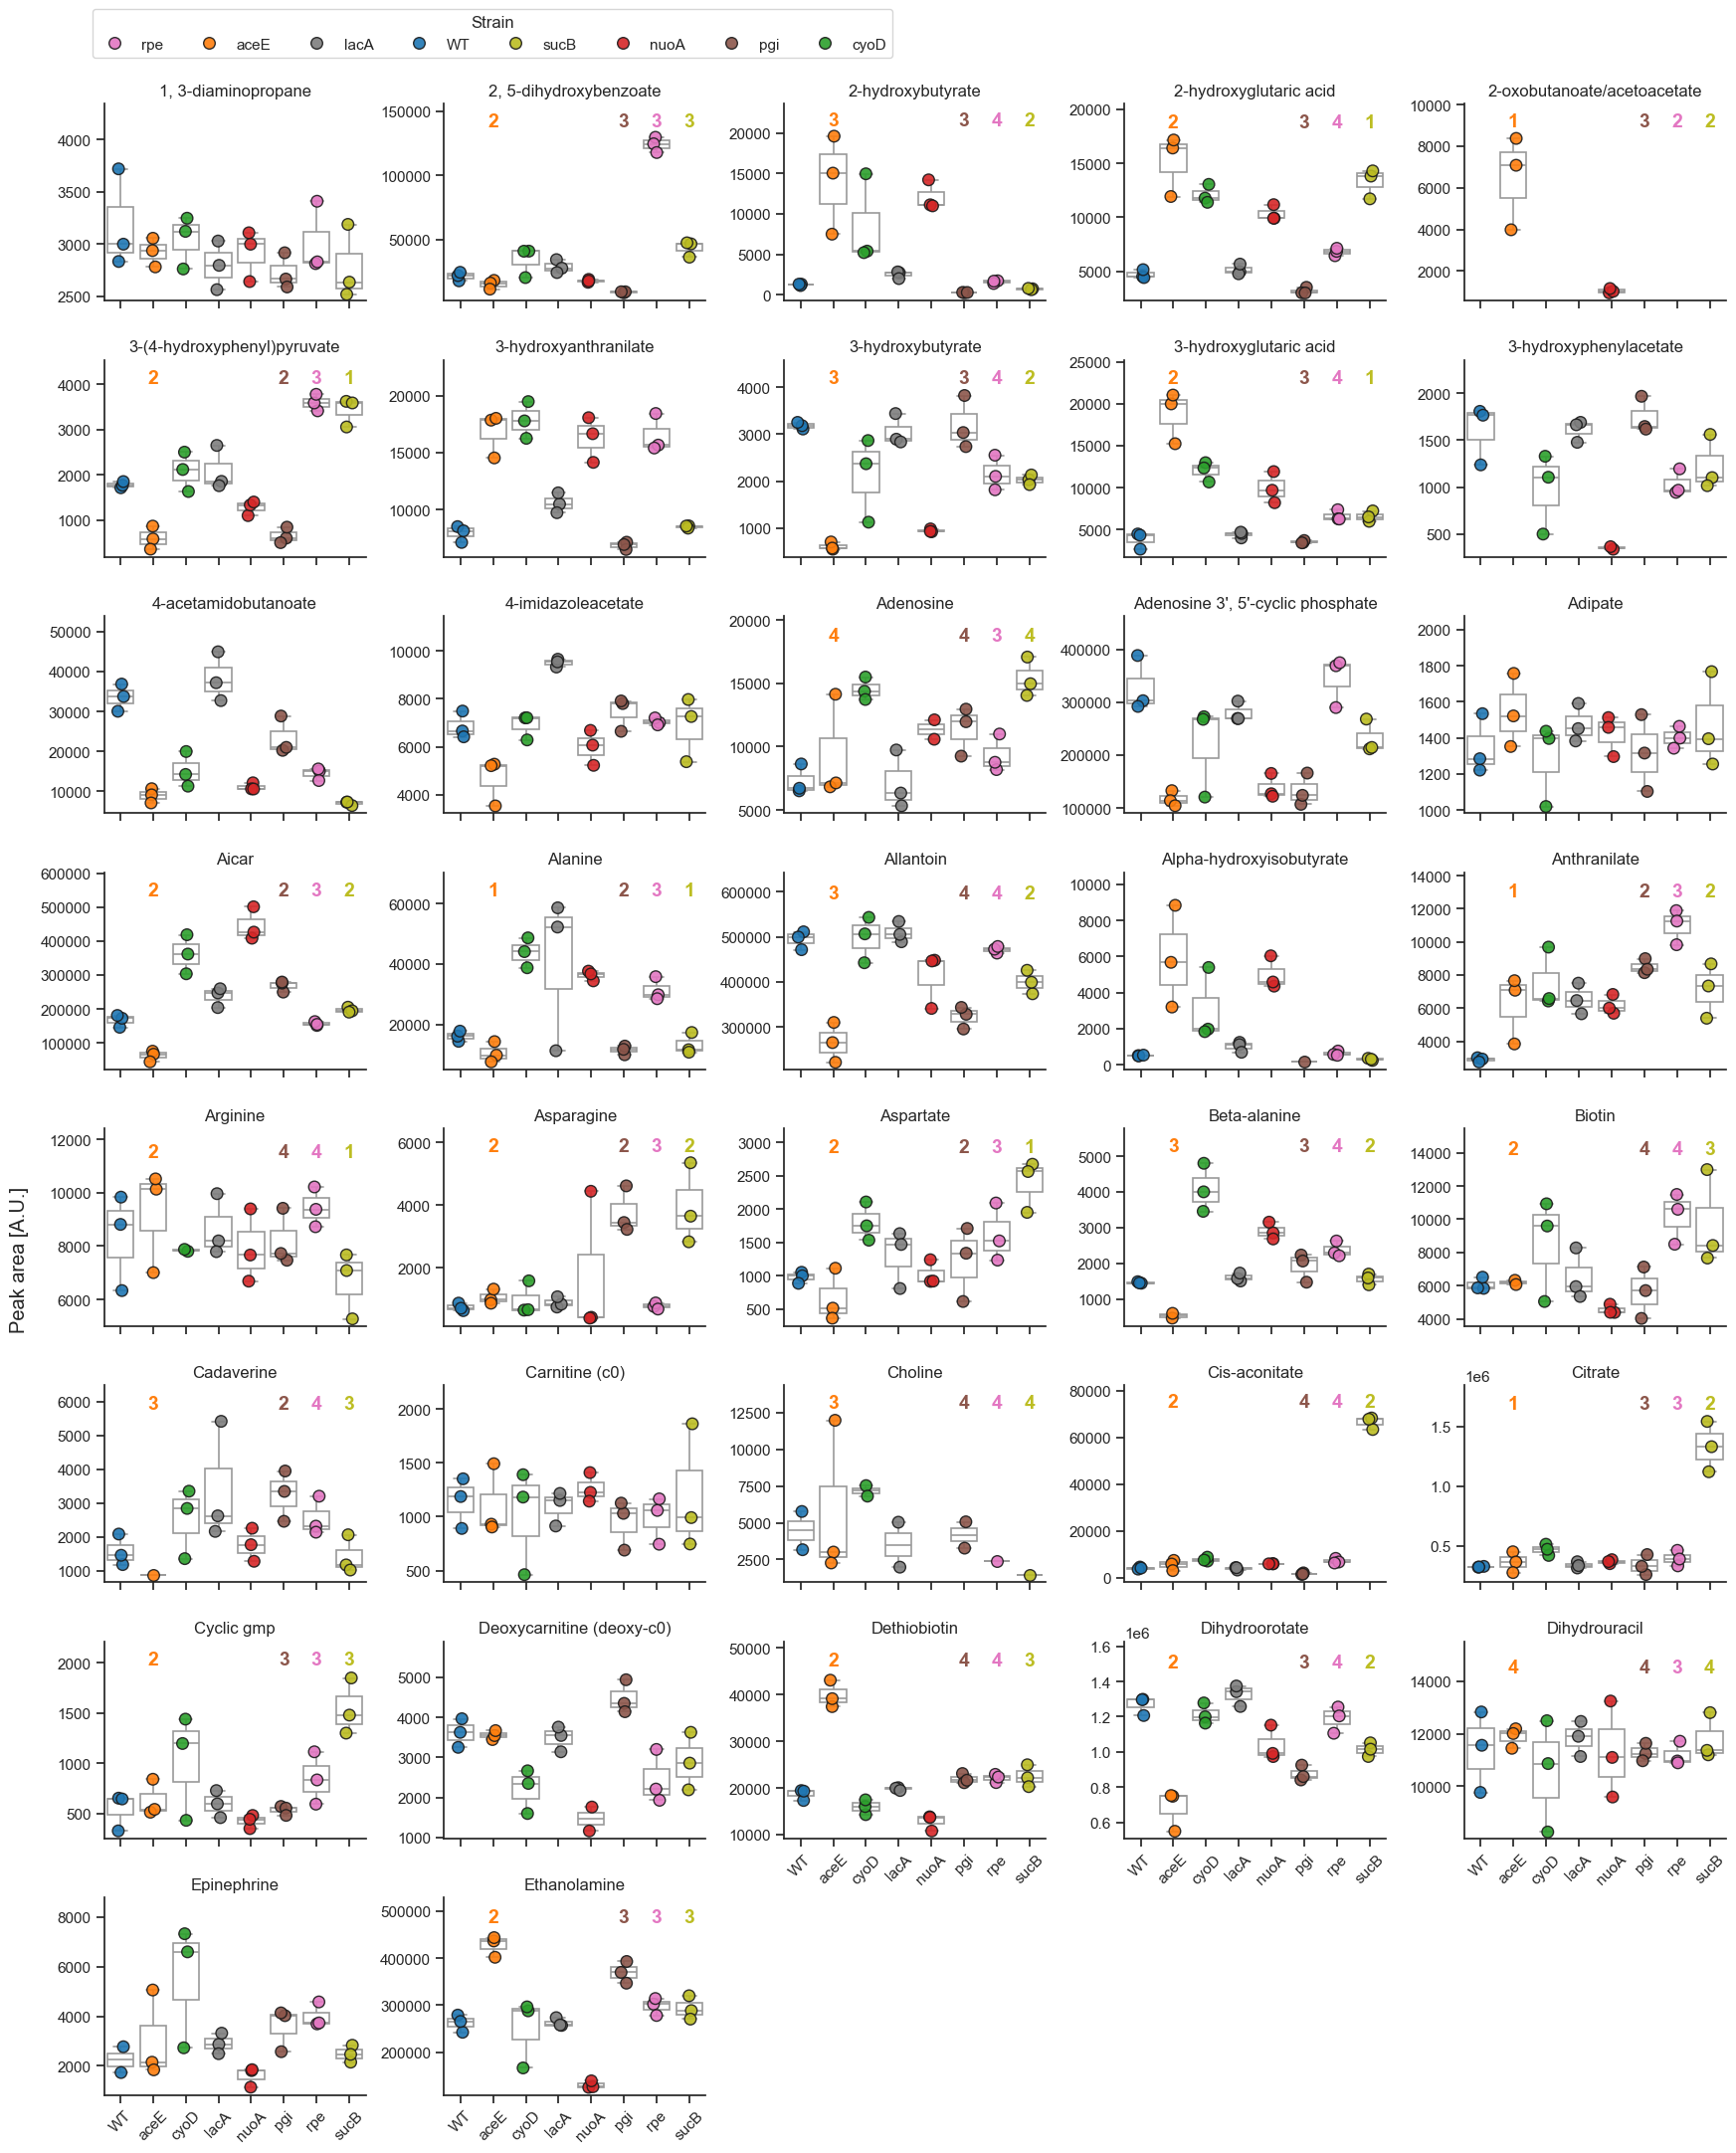

In [ ]:

# sns.set_theme(font_scale=1.2, style='ticks')
n3 = int(len(z_metabolites)/3)
first = z_metabolites[:n3]
second = z_metabolites[n3:2*n3]
third = z_metabolites[2*n3:]
idx1 = dfL_counts.Metabolite.isin(first)
g = sns.catplot(data = dfL_counts.loc[idx1], x = 'Strain', y = 'Counts', hue = 'Strain', order = exo_strains, palette=strain_colors,
            col = 'Metabolite',col_wrap=5, sharey=False, s = 70, alpha = 0.9, linewidth = 1, edgecolor='k',height=3, aspect=1.2,legend = True)
g.map_dataframe(sns.boxplot, x = 'Strain', y = 'Counts',color = 'w', fliersize = 0, linewidth = 1.2)
g.set_titles(col_template="{col_name}")
# Rotate x-tick labels for all axes
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('center')
annotate_reaction_distances(g, exo_strains, df_dist)
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0.06,1), ncol = 8, frameon = True)
g.set_axis_labels('', '')
g.fig.supylabel('Peak area [A.U.]')
plt.subplots_adjust(wspace=0.3, hspace=0.3, left = 0.07, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_1.pdf', bbox_inches='tight')
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_1.png', bbox_inches='tight', dpi = 300)


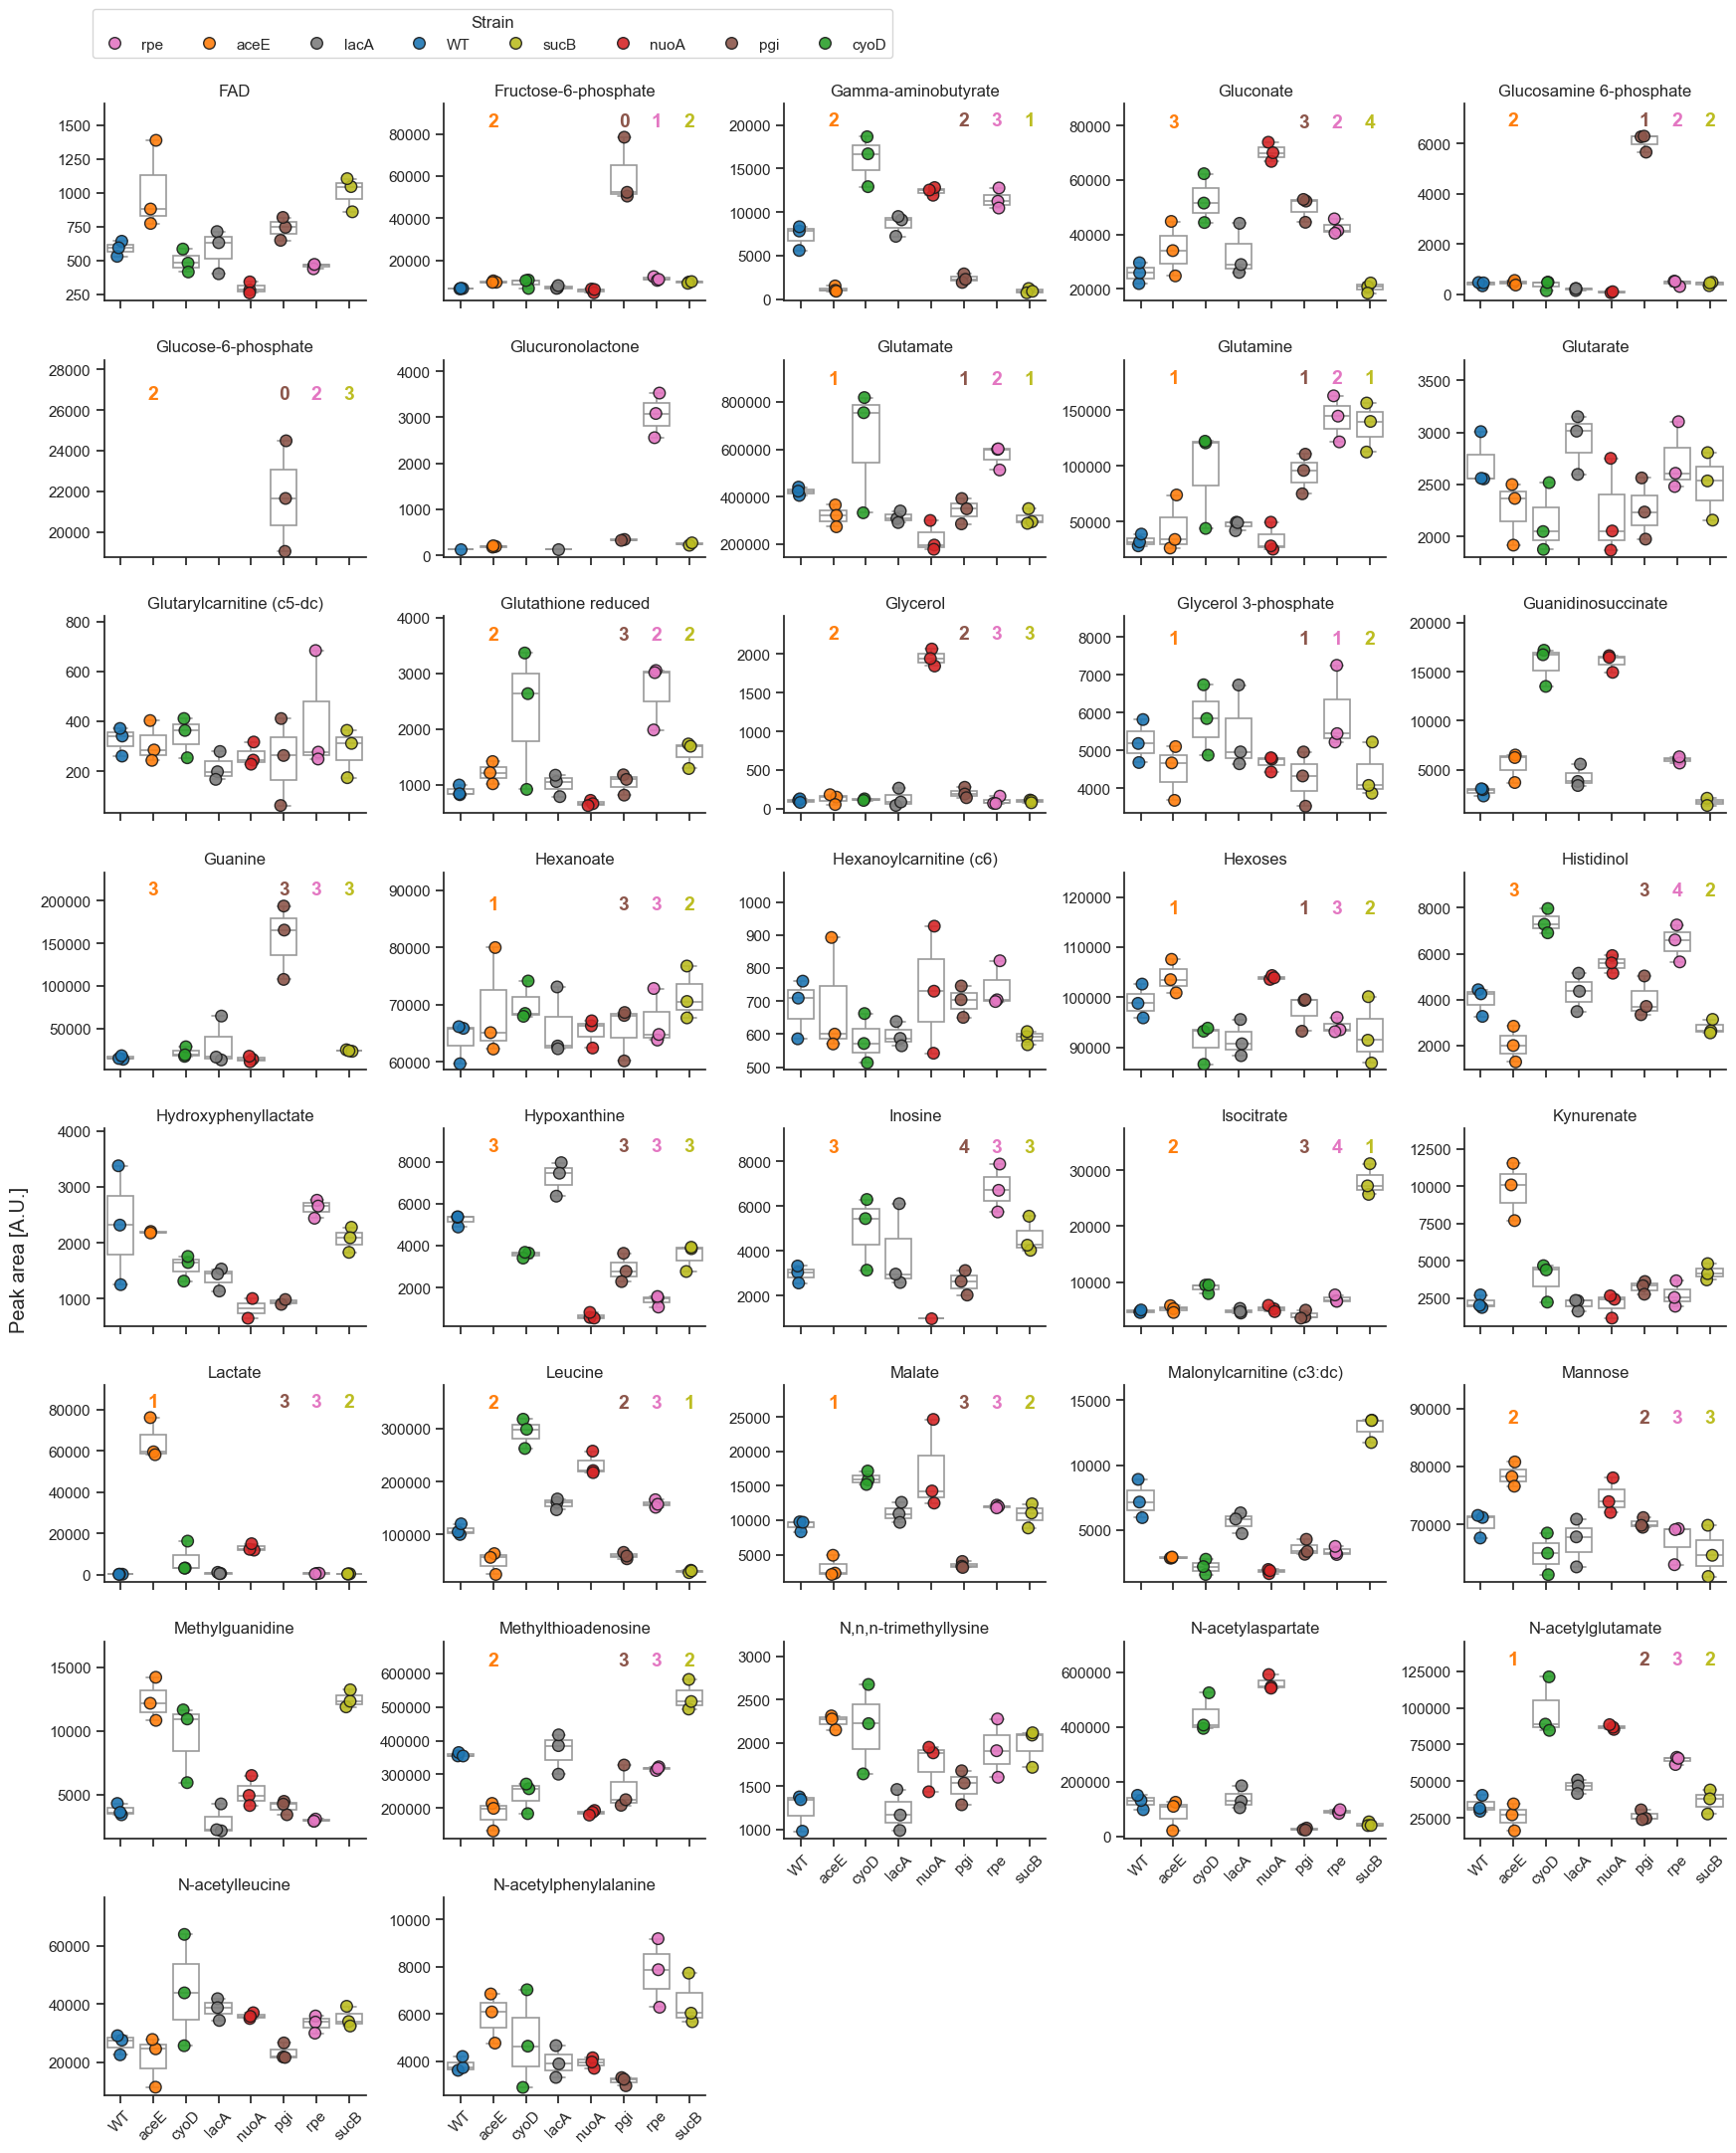

In [ ]:

# sns.set_theme(font_scale=1.2, style='ticks')
idx2 = dfL_counts.Metabolite.isin(second)

g = sns.catplot(data = dfL_counts.loc[idx2], x = 'Strain', y = 'Counts', hue = 'Strain', order = exo_strains, palette=strain_colors,
            col = 'Metabolite',col_wrap=5, sharey=False, s = 70, alpha = 0.9, linewidth = 1, edgecolor='k',height=3, aspect=1.2,legend = True)
g.map_dataframe(sns.boxplot, x = 'Strain', y = 'Counts',color = 'w', fliersize = 0, linewidth = 1.2)
g.set_titles(col_template="{col_name}")
# Rotate x-tick labels for all axes
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('center')
annotate_reaction_distances(g, exo_strains, df_dist)
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0.06,1), ncol = 8, frameon = True)

g.set_axis_labels('', '')
g.fig.supylabel('Peak area [A.U.]')
plt.subplots_adjust(wspace=0.3, hspace=0.3, left = 0.07, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_2.pdf', bbox_inches='tight')
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_2.png', bbox_inches='tight', dpi = 300)


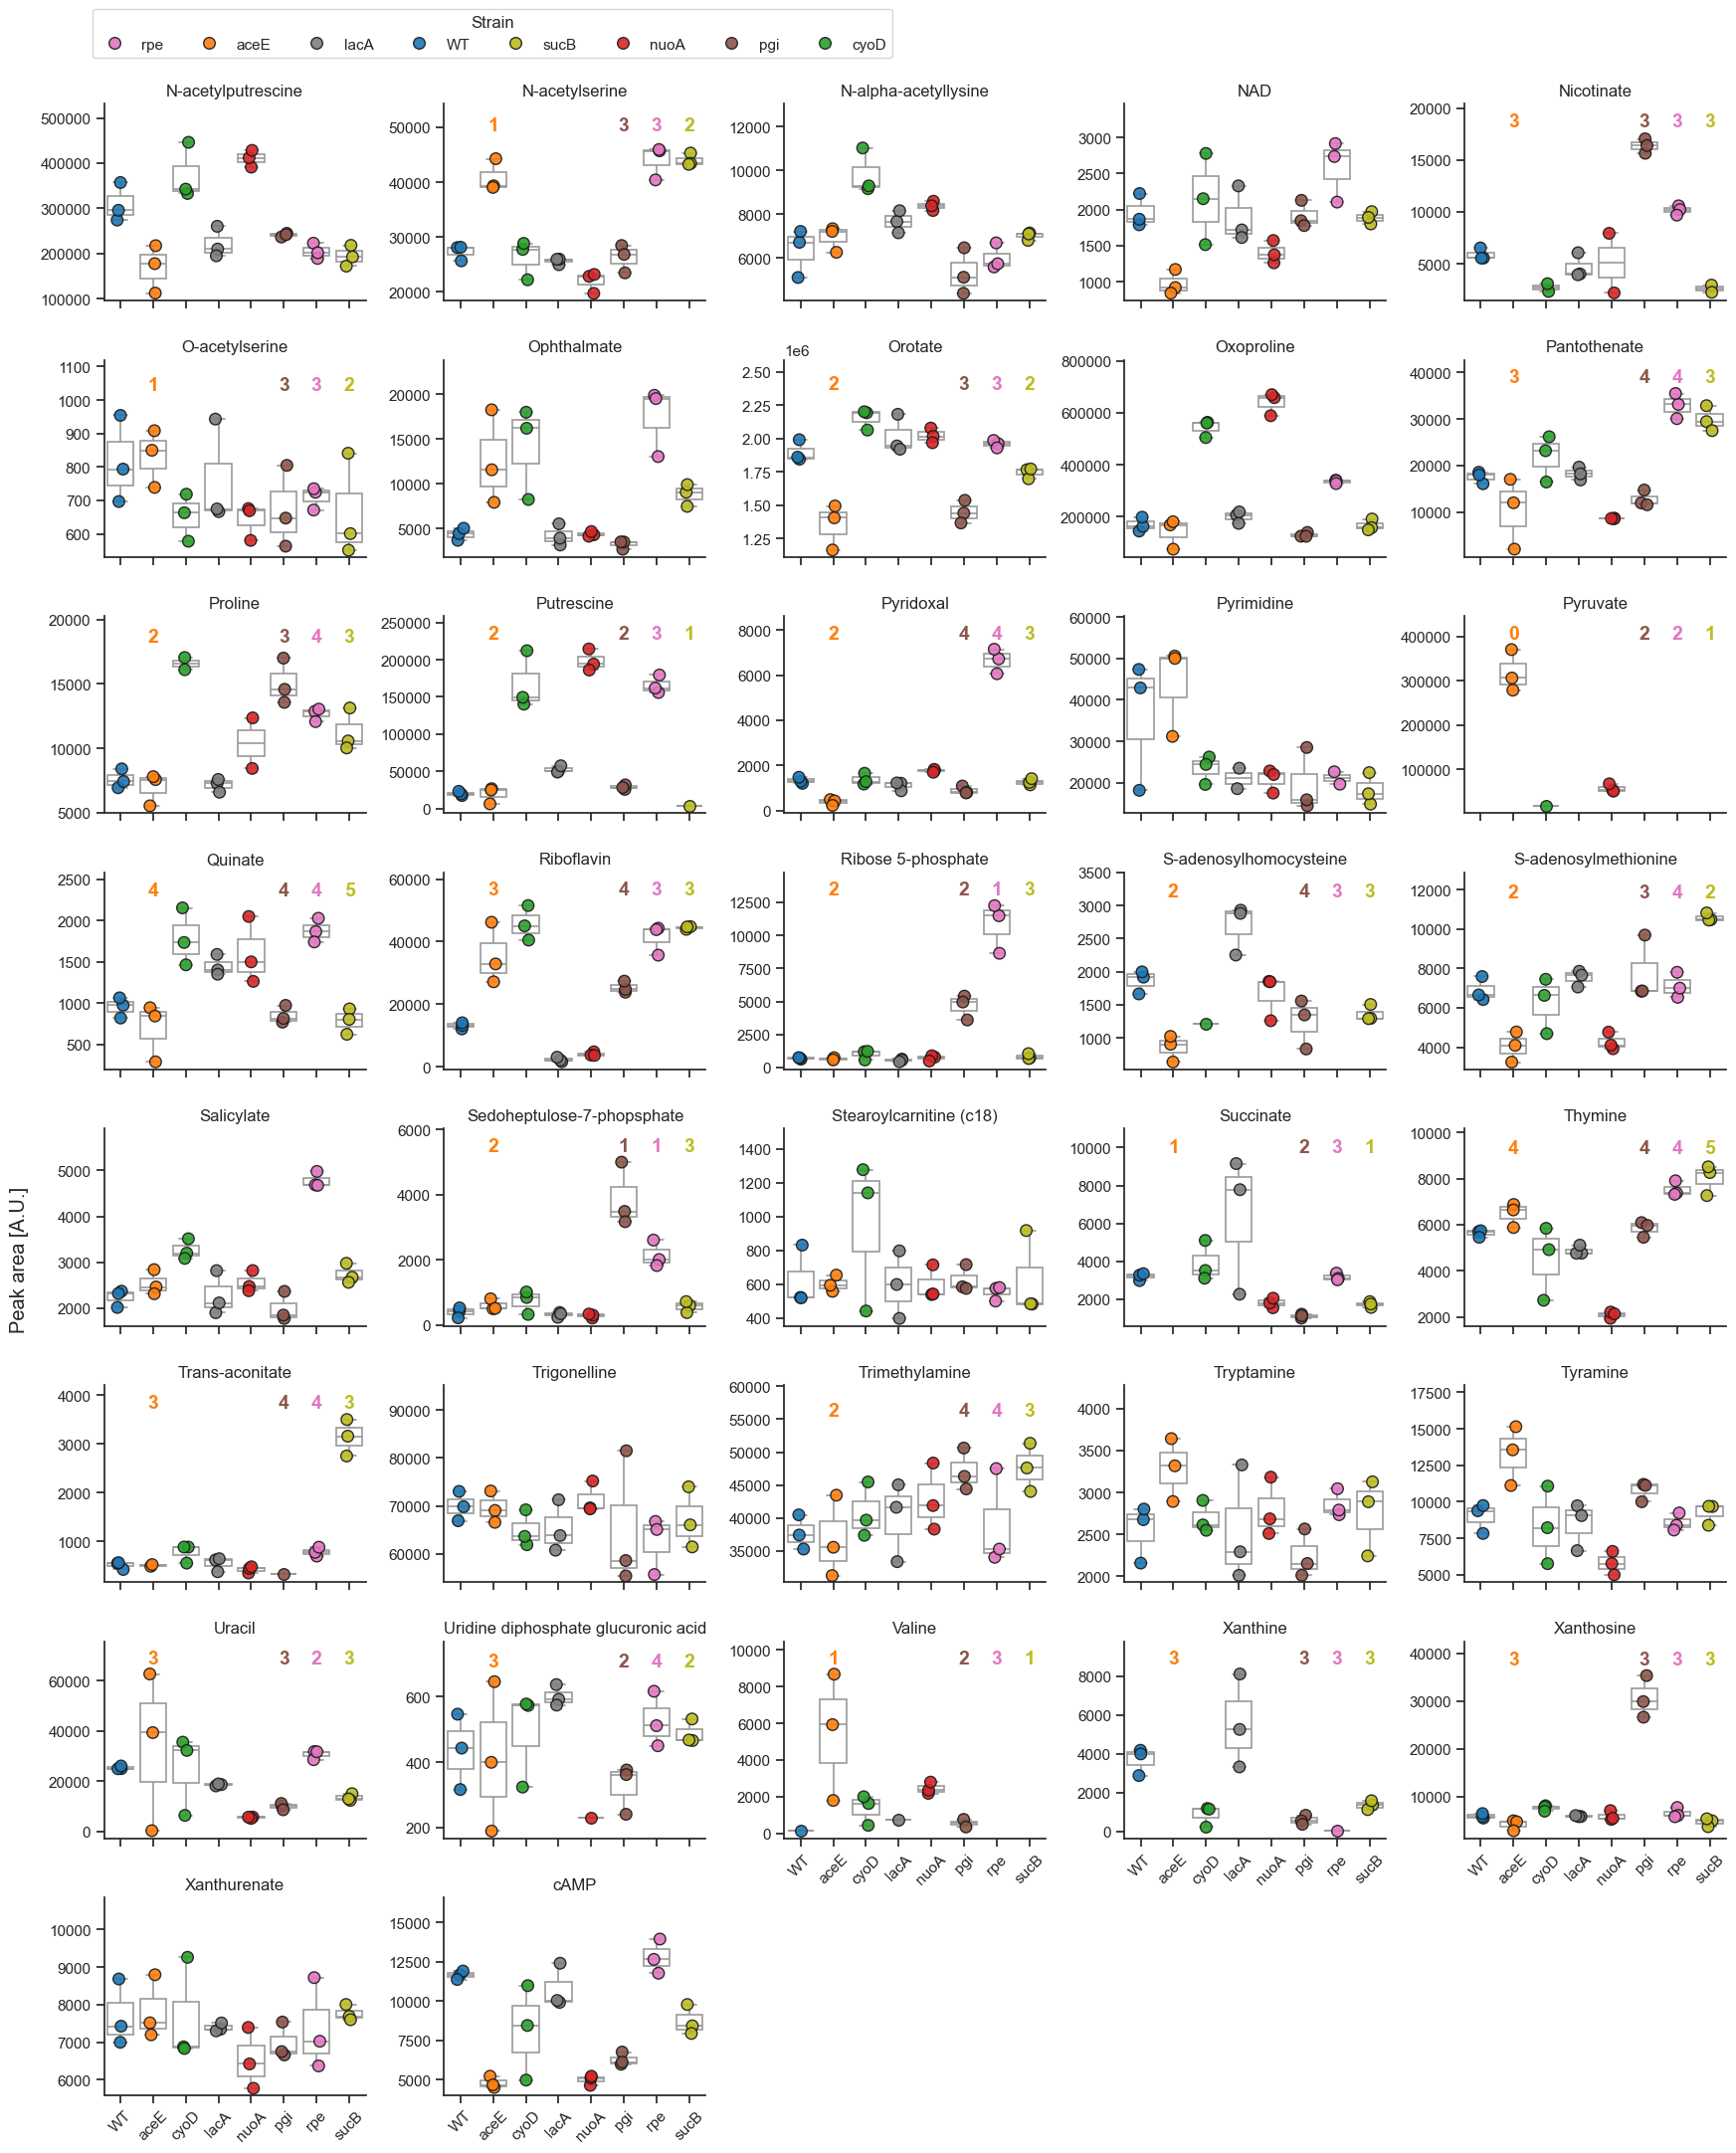

In [ ]:

# sns.set_theme(font_scale=1.2, style='ticks')
idx3 = dfL_counts.Metabolite.isin(third)

g = sns.catplot(data = dfL_counts.loc[idx3], x = 'Strain', y = 'Counts', hue = 'Strain', order = exo_strains, palette=strain_colors,
            col = 'Metabolite',col_wrap=5, sharey=False, s = 70, alpha = 0.9, linewidth = 1, edgecolor='k',height=3, aspect=1.2,legend = True)
g.map_dataframe(sns.boxplot, x = 'Strain', y = 'Counts',color = 'w', fliersize = 0, linewidth = 1.2)
g.set_titles(col_template="{col_name}")
# Rotate x-tick labels for all axes
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('center')
annotate_reaction_distances(g, exo_strains, df_dist)
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0.06,1), ncol = 8, frameon = True)

g.set_axis_labels('', '')
g.fig.supylabel('Peak area [A.U.]')
plt.subplots_adjust(wspace=0.3, hspace=0.3, left = 0.07, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_3.pdf', bbox_inches='tight')
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_3.png', bbox_inches='tight', dpi = 300)


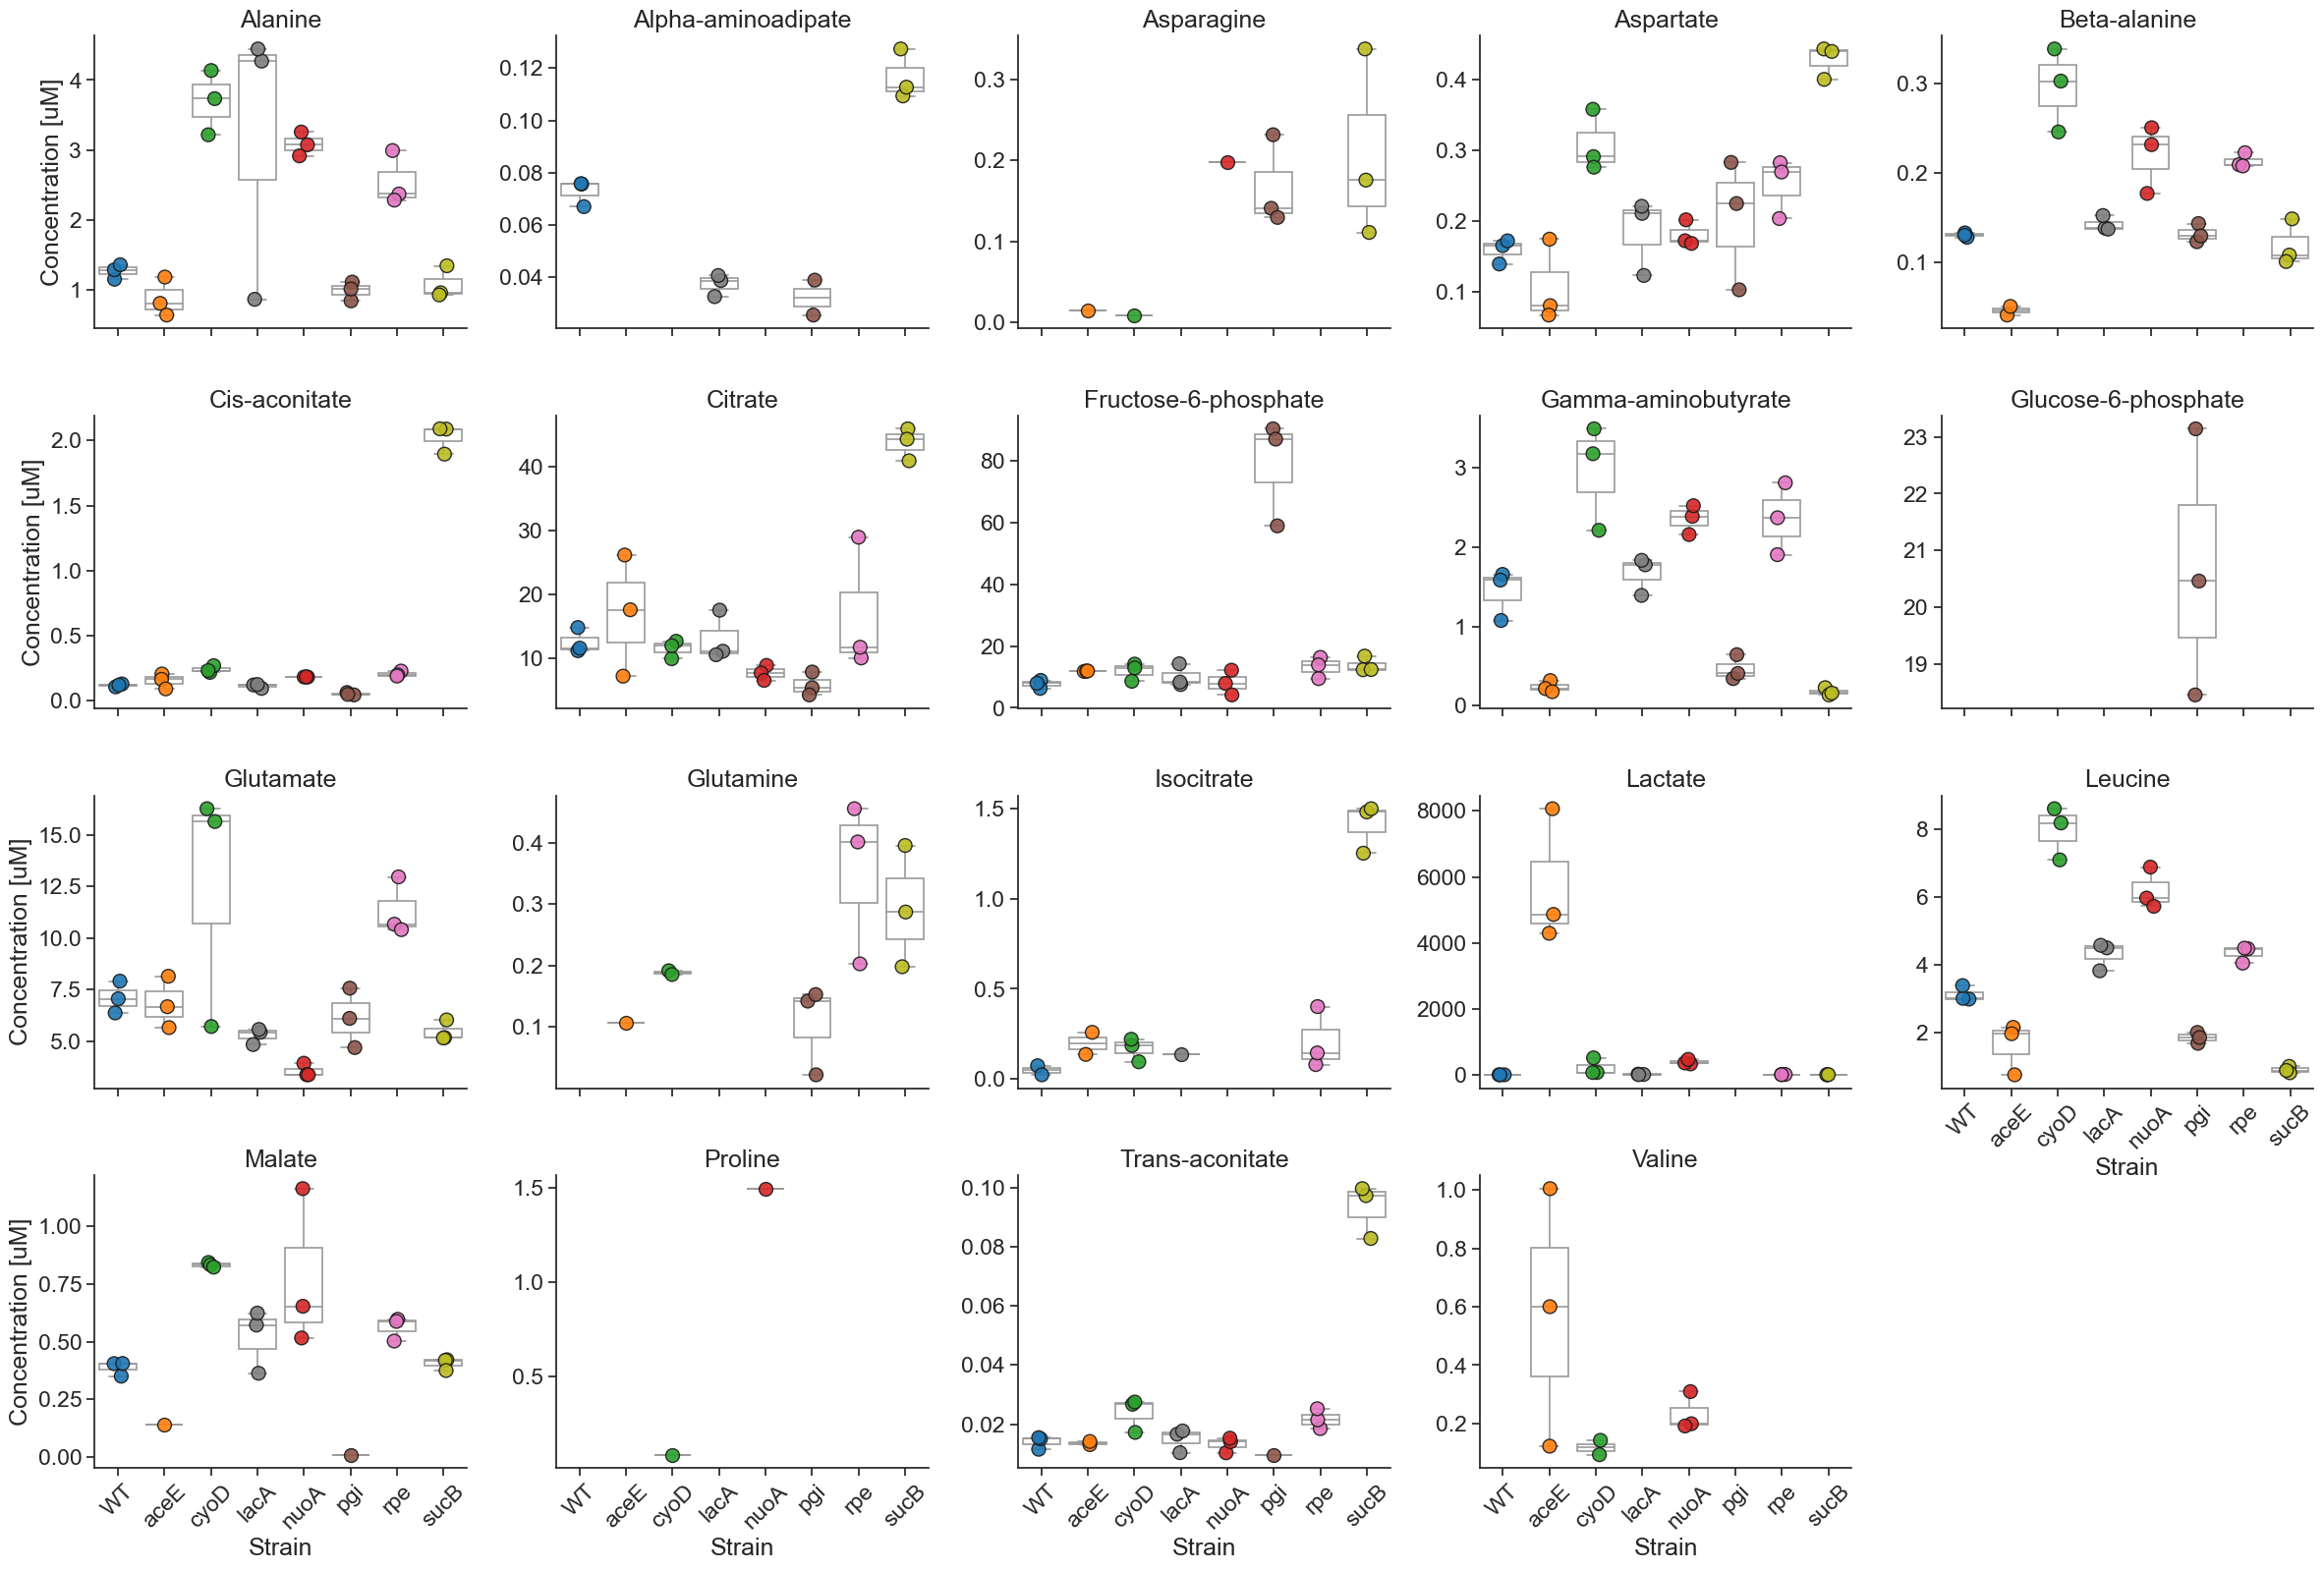

In [ ]:
sns.set_theme(font_scale=1.5, style='ticks')
g = sns.catplot(data = dfL_uM, x = 'Strain', y = 'Concentration [uM]', hue = 'Strain', order = exo_strains, palette=strain_colors,
            col = 'Metabolite',col_wrap=5, sharey=False, s = 100, alpha = 0.9, linewidth = 1, edgecolor='k',height=4, aspect=1.2,)
g.map_dataframe(sns.boxplot, x = 'Strain', y = 'Concentration [uM]',color = 'w', fliersize = 0, linewidth = 1.2)
g.set_titles(col_template="{col_name}")
# Rotate x-tick labels for all axes
for ax in g.axes.flat:
    # if (ax.get_ylim()[1]/ax.get_ylim()[0] > 10) or ((ax.get_ylim()[0] <=0) and (ax.get_ylim()[1] > 100)):
    # ax.set_yscale('log')
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('center')
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_uM.pdf', bbox_inches='tight')
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_uM.png', bbox_inches='tight', dpi = 300)

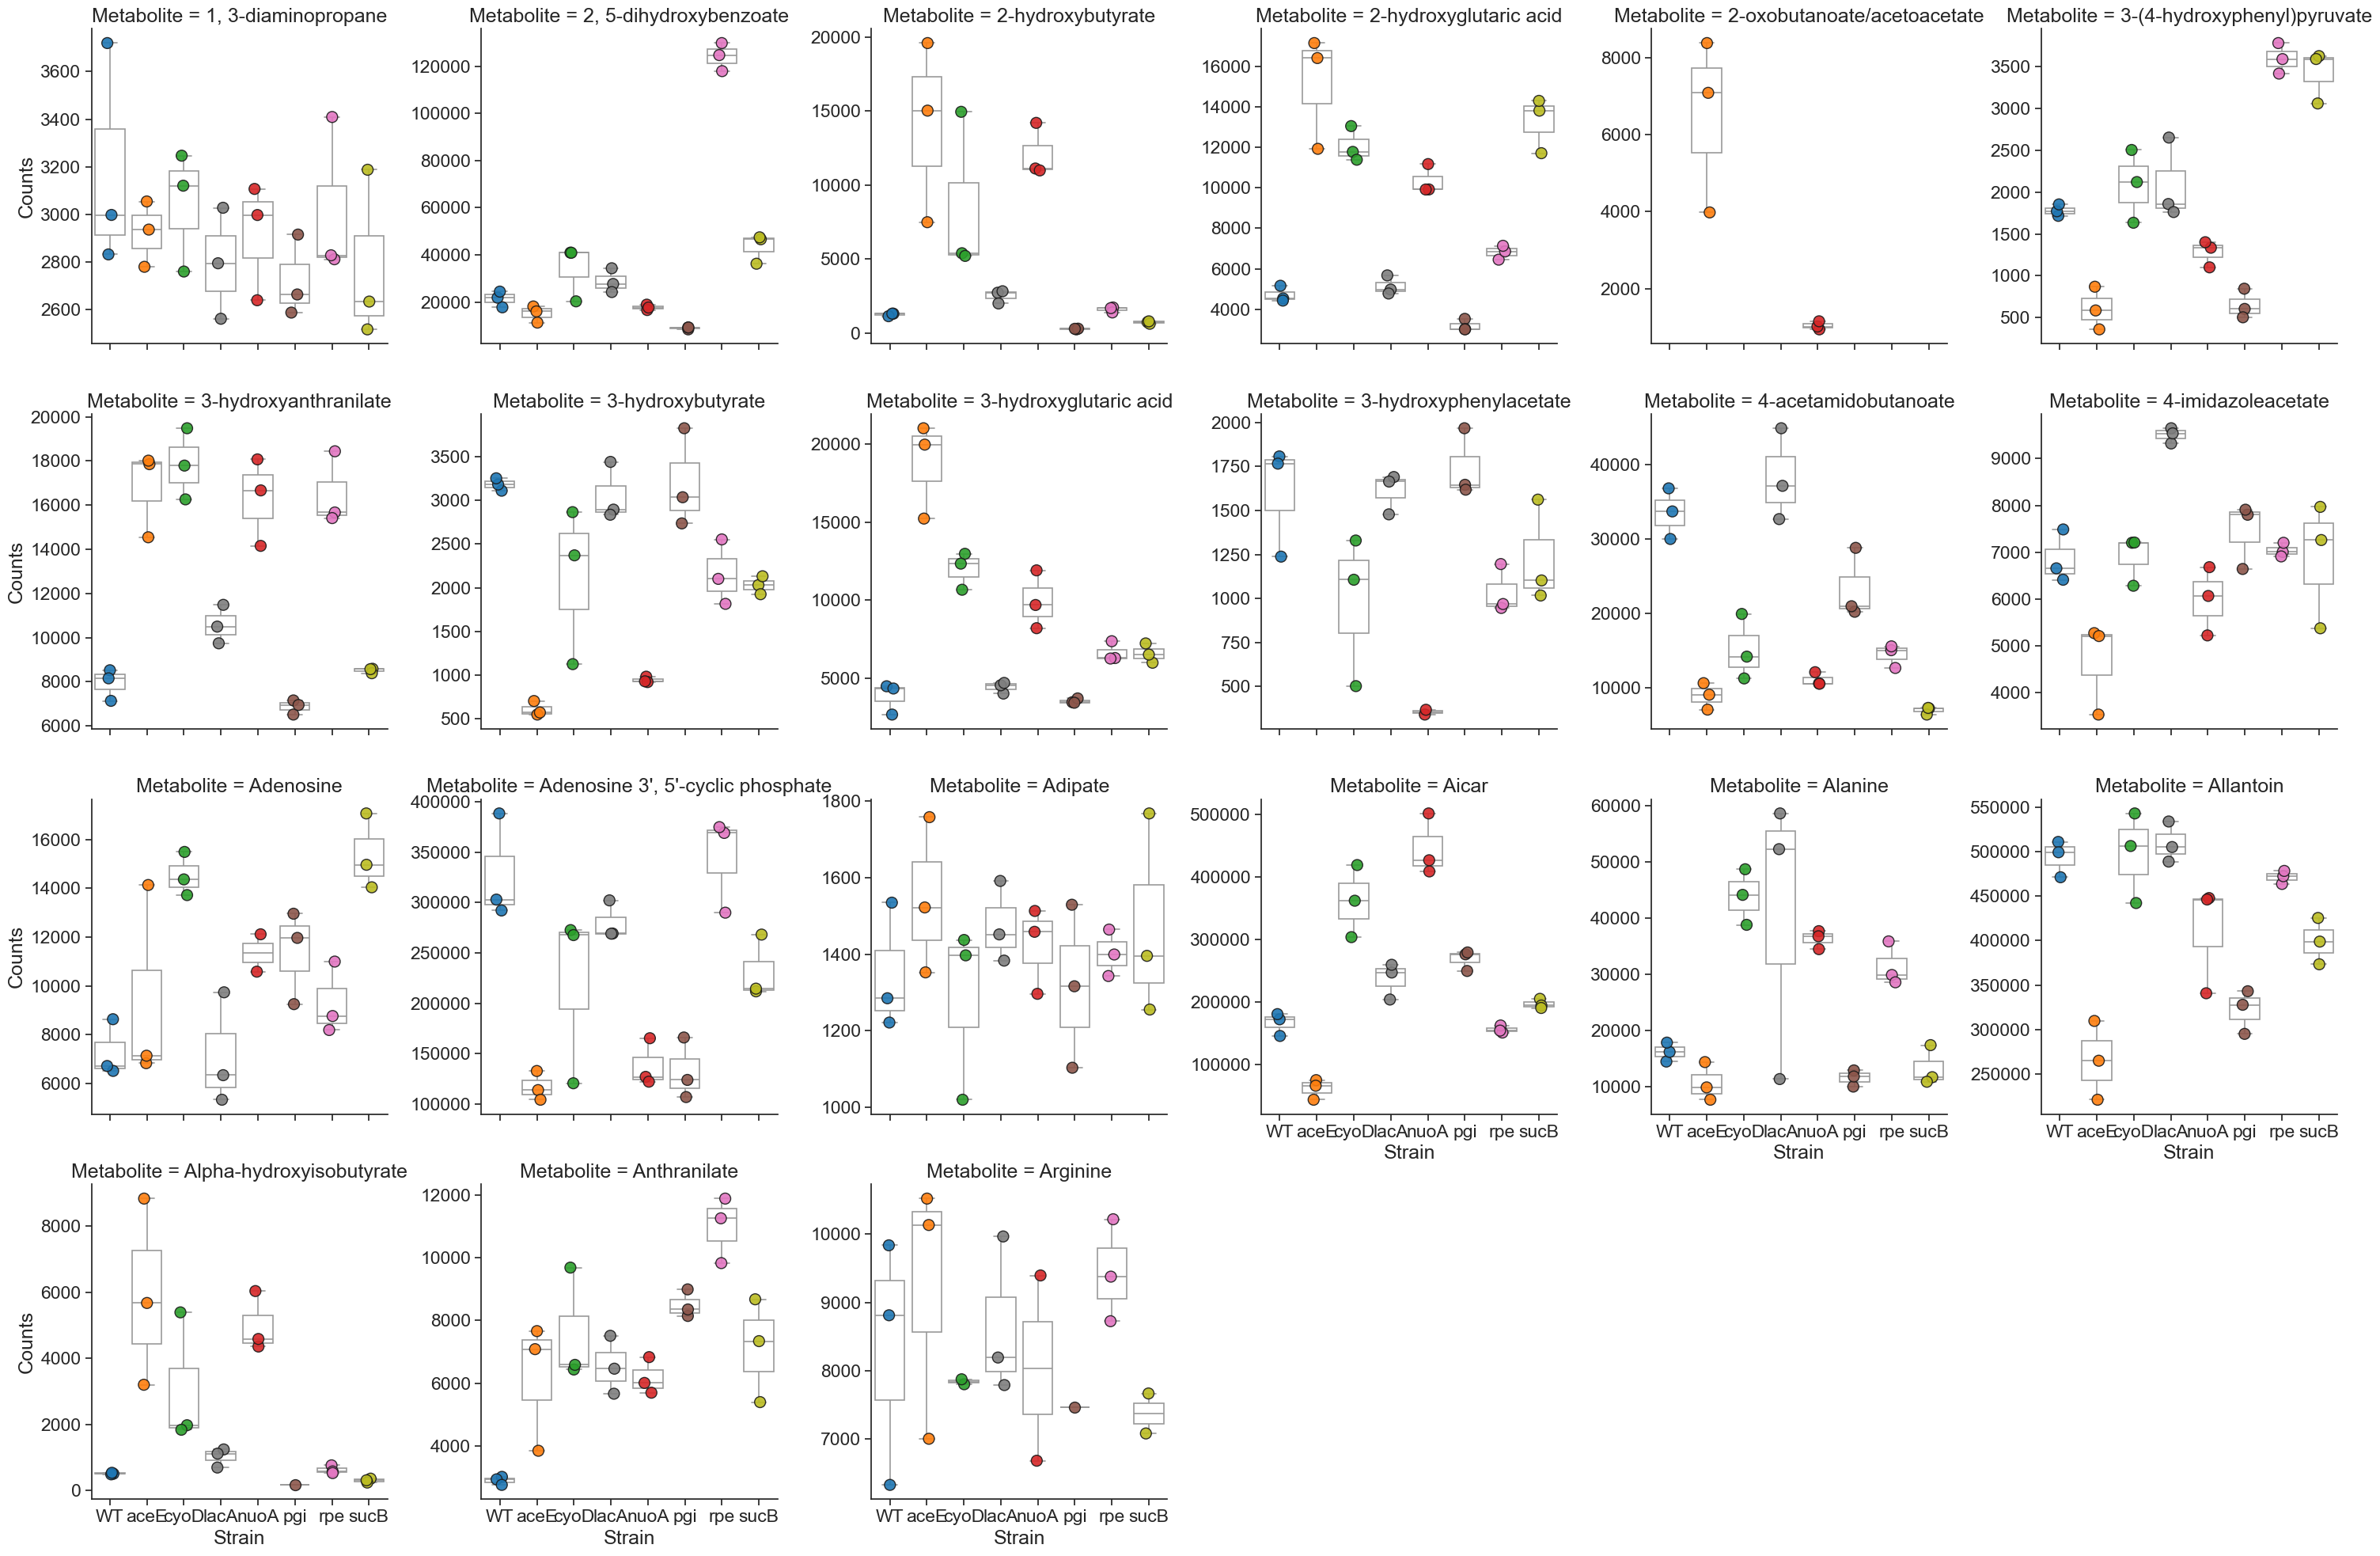

In [ ]:
g = sns.catplot(data = dfL_counts.iloc[:500], x = 'Strain', y = 'Counts', hue = 'Strain', order = exo_strains, palette=strain_colors,
            col = 'Metabolite',col_wrap=6, sharey=False, s = 100, alpha = 0.9, linewidth = 1, edgecolor='k',)
g.map_dataframe(sns.boxplot, x = 'Strain', y = 'Counts',color = 'w', fliersize = 0, linewidth = 1.2)

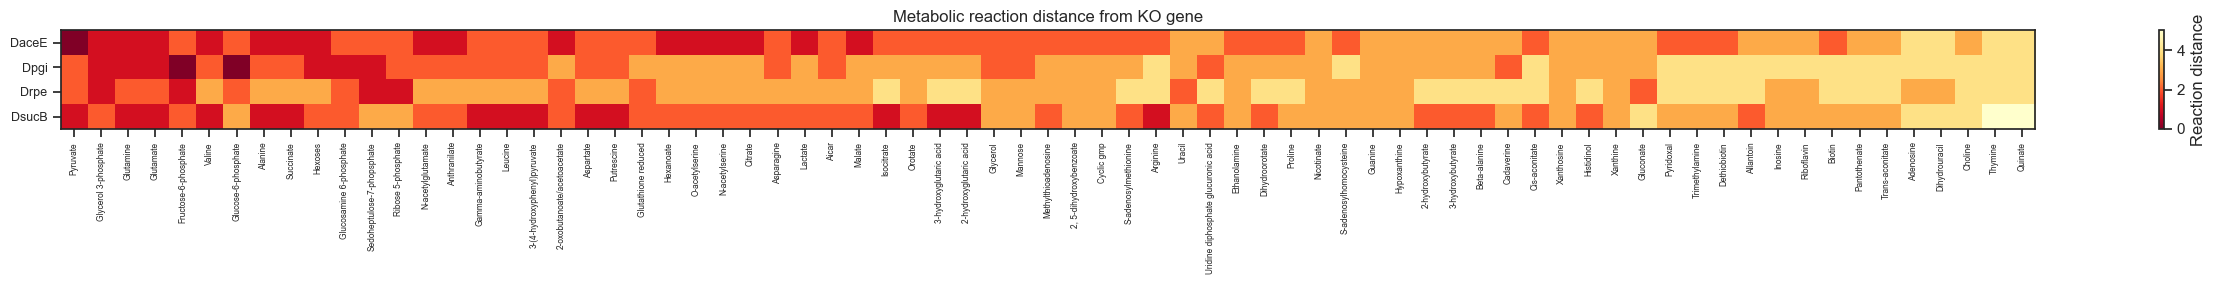

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_32553/2319937861.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['Absolute LogDiff'] = plot_df['LogDiff'].abs()


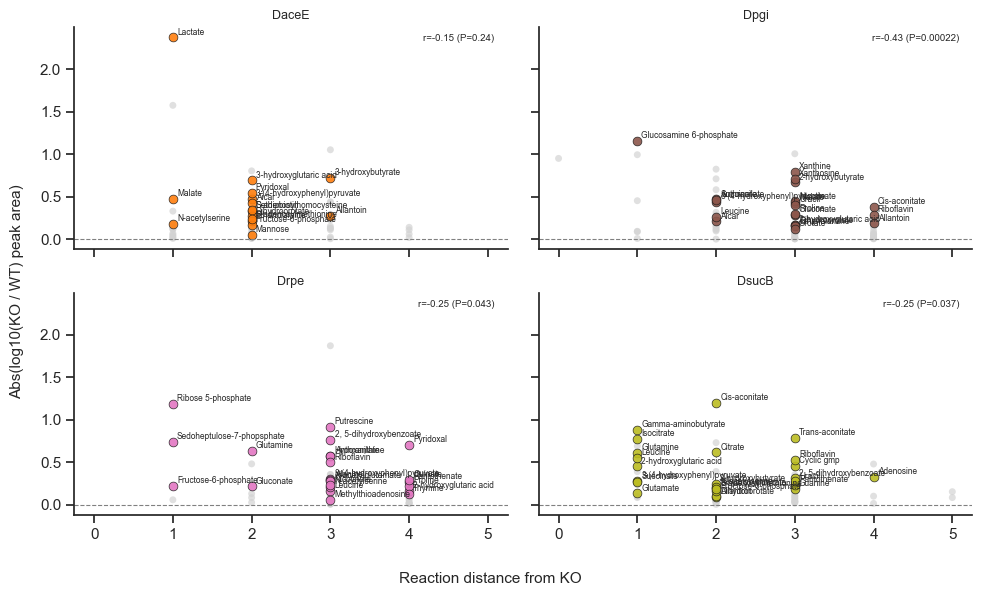

In [138]:

# ── Join distances with log fold-changes and p-values ─────────────────────────
df_dist_plot = df_dist.merge(df_log_diffs, on=['Strain', 'Metabolite'], how='left')
df_dist_plot = df_dist_plot.merge(
    pd.DataFrame([(s, met, p) for (s, met), p in counts_adjusted_p_values_dict.items()],
                 columns=['Strain', 'Metabolite', 'adj. pvalue']),
    on=['Strain', 'Metabolite'], how='left'
)
df_dist_plot['sig'] = df_dist_plot['adj. pvalue'] < 0.05

# ── 1. Heatmap: reaction distance, strains × metabolites ──────────────────────
hm_data = (df_dist.dropna(subset=['Reaction distance'])
           .pivot(index='Strain', columns='Metabolite', values='Reaction distance'))

met_order = hm_data.mean(axis=0).sort_values().index
strain_order = [s for s in exo_strains_x_wt if s in hm_data.index]
hm_data = hm_data.loc[strain_order, met_order]

fig, ax = plt.subplots(figsize=(max(10, len(met_order) * 0.35), 3))
im = ax.imshow(hm_data.values, aspect='auto', cmap='YlOrRd_r', interpolation='none')
plt.colorbar(im, ax=ax, label='Reaction distance')
ax.set_xticks(range(len(hm_data.columns)))
ax.set_xticklabels(hm_data.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(hm_data.index)))
ax.set_yticklabels([f'D{s}' for s in hm_data.index], fontsize=9)
ax.set_title('Metabolic reaction distance from KO gene')
plt.tight_layout()
plt.savefig(figure_folder / 'KEIO_distance_heatmap.pdf', bbox_inches='tight')
plt.show()

# ── 2. Scatter: reaction distance vs log fold-change, per strain ──────────────
plot_df = df_dist_plot.dropna(subset=['Reaction distance', 'LogDiff'])
plot_df['Absolute LogDiff'] = plot_df['LogDiff'].abs()

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()
for i, strain in enumerate([s for s in exo_strains_x_wt if s in ['aceE', 'pgi', 'rpe', 'sucB']]):
    ax = axes[i]
    d = plot_df[plot_df.Strain == strain]
    ax.scatter(d.loc[~d.sig, 'Reaction distance'],
               d.loc[~d.sig, 'Absolute LogDiff'],
               color='lightgrey', edgecolor='none', s=25, alpha=0.7, zorder=1)
    ax.scatter(d.loc[d.sig, 'Reaction distance'],
               d.loc[d.sig, 'Absolute LogDiff'],
               color=strain_colors[strain], edgecolor='k', linewidth=0.5,
               s=40, alpha=0.9, zorder=2)
    for _, row in d[d.sig].iterrows():
        ax.annotate(row.Metabolite, (row['Reaction distance'], row['Absolute LogDiff']),
                    fontsize=6, ha='left', xytext=(3, 2), textcoords='offset points')
    ax.axhline(0, ls='--', c='grey', lw=0.8)
    if len(d) >= 5:
        r, p = st.pearsonr(d['Reaction distance'], d['Absolute LogDiff'])
        ax.text(0.97, 0.97, f'r={r:.2f} (P={p:.2g})',
                transform=ax.transAxes, ha='right', va='top', fontsize=7)
    ax.set_title(f'D{strain}', fontsize=9)

fig.supxlabel('Reaction distance from KO', fontsize=11)
fig.supylabel('Abs(log10(KO / WT) peak area)', fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig(figure_folder / 'KEIO_distance_vs_logFC.pdf', bbox_inches='tight')
plt.show()


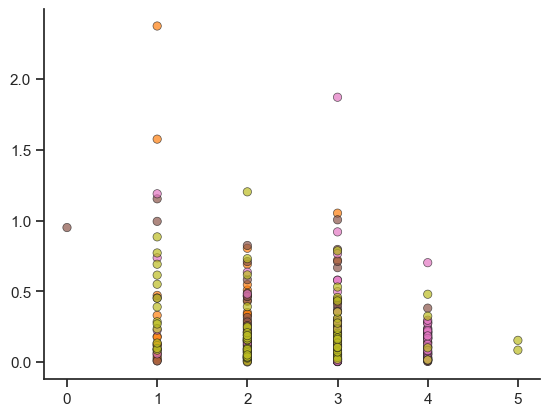

In [ ]:
plt.scatter(plot_df['Reaction distance'], plot_df['Absolute LogDiff'],
            c=plot_df['Strain'].map(strain_colors), alpha=0.7, edgecolor='k', linewidth=0.5)

for strain, grp in plot_df.groupby('Strain'):
    if len(grp) < 3:
        continue
    x = grp['Reaction distance'].values
    y = grp['Absolute LogDiff'].values
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    plt.plot(x_line, m * x_line + b, color=strain_colors.get(strain, 'grey'), linewidth=1.5)

sns.despine()


In [132]:
d

,Strain,Metabolite,Reaction distance,Path (reactions),LogDiff,adj. pvalue,sig,Absolute LogDiff
334,sucB,"2, 5-dihydroxybenzoate",3.0,AKGDH -> (akg) -> SEPHCHCS -> (ichor) -> ICHOR...,0.308950,0.044475,True,0.308950
335,sucB,2-hydroxybutyrate,2.0,AKGDH -> (akg) -> ABTA -> (sucsal) -> GHBDHx,-0.243624,0.028065,True,0.243624
336,sucB,2-hydroxyglutaric acid,1.0,AKGDH -> (akg) -> AHGDx,0.450869,0.031569,True,0.450869
338,sucB,3-(4-hydroxyphenyl)pyruvate,1.0,AKGDH -> (akg) -> TYRTA,0.284376,0.042664,True,0.284376
340,sucB,3-hydroxybutyrate,2.0,AKGDH -> (akg) -> ABTA -> (sucsal) -> GHBDHx,-0.195471,0.004851,True,0.195471
...,...,...,...,...,...,...,...,...
434,sucB,Trimethylamine,3.0,AKGDH -> (succoa) -> PPCSCT -> (succ) -> FRD2 ...,0.101634,0.057359,False,0.101634
437,sucB,Uracil,3.0,AKGDH -> (akg) -> GLUSy -> (gln__L) -> GLUPRT ...,-0.274916,0.019097,True,0.274916
438,sucB,Uridine diphosphate glucuronic acid,2.0,AKGDH -> (akg) -> UDPKAAT -> (udpLa4o) -> UDPGDC,0.050081,0.625372,False,0.050081
440,sucB,Xanthine,3.0,AKGDH -> (akg) -> GLUSy -> (gln__L) -> GLUPRT ...,-0.431655,0.056223,False,0.431655


In [ ]:
df_dist.dropna(inplace=True)

In [ ]:
df_dist.loc[df_dist['Metabolite'] == 'Aspartate']

,Strain,Metabolite,Reaction distance,Path (reactions)
22,aceE,Aspartate,2.0,PDH -> (pyr) -> ALATA_L -> (akg) -> ASPTA
133,pgi,Aspartate,2.0,PGI -> (f6p) -> GF6PTA -> (gln__L) -> ASNS1
244,rpe,Aspartate,3.0,RPE -> (xu5p__D) -> TKT2 -> (f6p) -> GF6PTA ->...
355,sucB,Aspartate,1.0,AKGDH -> (akg) -> ASPTA


# Read in metabolomics data from Fuhrer et al

In [ ]:
metabolomics_folder = Path('../../data/fuhrer_2017/')
neg_zscore = pd.read_csv(metabolomics_folder/'zscore_neg.tsv', sep = '\t', header=None)
pos_zscore = pd.read_csv(metabolomics_folder/'zscore_pos.tsv', sep = '\t', header=None)
zscores = pd.concat([neg_zscore, pos_zscore])
met_info = pd.read_csv(metabolomics_folder / 'metabolite_info.csv')
met_info = met_info.iloc[1:,:4]
sample_info = pd.read_csv(metabolomics_folder / 'strain_ids.csv', header=None)
zscores.columns = [x[0] for x in sample_info.values]

In [ ]:
met_info.head(20)

,Ionization Mode,Ion Index,m/z,"Annotations (Compound Name, Modification, Sum-Formula, KEGG Code, HMDB Code)"
1,neg,1.0,56.996,no annotation
2,neg,2.0,57.035,2-Oxobutanoate -CO2-H(+) C4H6O3 C00109 HMDB00005
3,neg,3.0,57.056,no annotation
4,neg,4.0,58.038,Acetone [+1]-H(+) C3H6O C00207 HMDB01659
5,neg,5.0,59.014,Acetate -H(+) C2H4O2 C00033 HMDB00042
6,neg,6.0,59.050,4-Hydroxybutanoic acid -CO2-H(+) C4H8O3 C00989...
7,neg,7.0,59.071,no annotation
8,neg,8.0,59.105,no annotation
9,neg,9.0,59.146,no annotation
10,neg,10.0,59.986,HCO3- -H(+) HCO3 C00288 HMDB00595


In [ ]:
for i, row in met_info.iterrows():
    annotations = row['Annotations (Compound Name, Modification, Sum-Formula, KEGG Code, HMDB Code)'].split(' ')
    if annotations[0] == 'no':
        continue
    else:
        if len(annotations) > 5:
            j = len(annotations) - 5
            name = ' '.join(annotations[:j+1])
            print(name)
        elif len(annotations) == 5:
            name = annotations[0]
            j = 0

        if len(annotations) >= 5:
            met_info.at[i, 'Name'] = name
            met_info.at[i, 'Sum-Formula'] = annotations[2+j]
            met_info.at[i, 'KEGG Code'] = annotations[3+j]
            met_info.at[i, 'HMDB Code'] = annotations[4+j]
        else:
            break


4-Hydroxybutanoic acid
Carbonic acid
Butanoic acid
3-Methyl-2-oxobutanoic acid
L-Aspartate 4-semialdehyde
Carbonic acid
Ethylene glycol
Butanoic acid
Glycerone phosphate
3-Methylbutanoic acid
4-Hydroxybutanoic acid
Benzyl alcohol
3-Methyl-2-oxobutanoic acid
3-Methyl-2-oxobutanoic acid
Benzyl alcohol
Octanoic acid
3-Methyl-2-oxobutanoic acid
Coniferyl alcohol
3-Methyl-2-oxobutanoic acid
Acetyl phosphate
Choline phosphate
2-Hydroxymuconate semialdehyde
cis-2-Carboxycyclohexyl-acetic acid
Octanoic acid
Octanoic acid
Cinnamyl alcohol
3-(Methylthio)propionic acid
Acetyl phosphate
Nitrous oxide
2-Hydroxymuconate semialdehyde
Sinapyl alcohol
Glycerone phosphate
9-Oxononanoic acid
Coniferyl aldehyde
Coniferyl alcohol
Carbonic acid
Ethylene glycol
Choline phosphate
Glycerone phosphate
sn-Glycerol 3-phosphate
Decanoic acid
D-Gluconic acid
Carbonic acid
Coniferyl alcohol
D-Erythrose 4-phosphate
Coniferyl aldehyde
Decahydro-2-naphthoic acid
Dodecanoic acid
Dihydroclavaminic acid
Dodecanoic acid
D-

In [ ]:
zscores.index = met_info.Name

In [ ]:
met_info['Name'].to_csv(metabolomics_folder / 'metabolite_names.csv', index = False)

In [ ]:
pd.Series(z_metabolites).to_csv(data_folder_1 / 'metabolite_names.csv', index = False)

## Map 


In [ ]:
# Redo mapping, only focusing on protonated metabolites 

In [ ]:
metabolite_mapping = pd.read_csv(metabolomics_folder/'metabolite_mapping.csv').iloc[:, :2]
metabolite_mapping.columns = ['Ex name', 'In name']

In [ ]:
met_map = metabolite_mapping.set_index('Ex name')['In name'].to_dict()

In [ ]:
data_comp = []
for strain in exo_strains_x_wt:
    for m in z_metabolites:
        m_in = met_map[m]
        ex_zscores = df_z_scores.loc[df_z_scores.Strain == strain, m].mean()
        ex_wt_zscores = df_z_scores.loc[df_z_scores.Strain == 'WT', m].mean()

        in_zscores = zscores.at[m_in, strain]
        in_wt_zscores = zscores.at[m_in, 'wt']
        data_comp.append([strain, m, ex_zscores-ex_wt_zscores, (in_zscores.mean()-in_wt_zscores.mean())])
        

    

In [ ]:
zscores.at[m_in, strain]

Name
3',5'-Cyclic AMP    0.5774
3',5'-Cyclic AMP    0.8344
3',5'-Cyclic AMP    0.5725
3',5'-Cyclic AMP    2.3965
3',5'-Cyclic AMP    1.2605
3',5'-Cyclic AMP    1.1067
3',5'-Cyclic AMP    1.0569
Name: lacA, dtype: float64

In [ ]:
df_comp = pd.DataFrame(data_comp, columns=['Strain', 'Metabolite', 'Ex', 'In'])
df_comp.dropna(inplace=True)

PearsonRResult(statistic=np.float64(0.09099211498615703), pvalue=np.float64(0.013278648929842688))

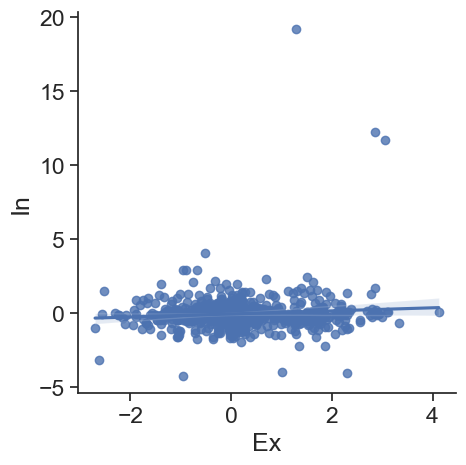

In [ ]:
sns.lmplot(data = df_comp, x = 'Ex', y = 'In')
st.spearmanr(df_comp.Ex, df_comp.In)
st.pearsonr(df_comp.Ex, df_comp.In)